# GrIS melt causality

Author: Ziqi Yin

Last modified: 2026 Jun 2

Description: Causal inference of Greenland Ice Sheet summer surface melt
- Method: PCMCI+
- Period: 1975-2014, use four 10-year periods
- Frequency: daily
- Region: ablation zone
- Variables: SWn, LWn, SH, LH
- Source: MAR v3.14, 10km

In [1]:
import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from matplotlib.gridspec import GridSpec

import sys
home_dir = '/glade/work/ziqiyin/'
sys.path.insert(0, home_dir)
from copy import deepcopy

import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from scipy.stats import gaussian_kde
import warnings
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings(action='ignore')

import tigramite
import tigramite.data_processing as pp
import tigramite.plotting as tp

from tigramite.models import LinearMediation, Models
from tigramite.causal_effects import CausalEffects

from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.independence_tests.robust_parcorr import RobustParCorr
from tigramite.independence_tests.gpdc import GPDC

import tifffile

import cartopy
import cartopy.crs as ccrs
crs_np = ccrs.NorthPolarStereo(central_longitude=0)
crs_ll = ccrs.PlateCarree()

# https://github.com/hhuangwx/cmaps
import cmaps

import geopandas as gp
import regionmask

# For regridding
import os
import ESMF

import datetime
import pandas as pd
from collections import Counter, defaultdict

ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/ziqiyin/conda-envs/my-npl-202306a/share/proj failed


In [2]:
# Function to remove seasonal mean and divide by seasonal standard deviation
def anomalize(dataseries, divide_by_std=True, reference_bounds=None, cycle_length=365, return_cycle=False):
    if reference_bounds is None:
        reference_bounds = (0, len(dataseries))

    anomaly = np.copy(dataseries)
    for t in range(cycle_length):
        if return_cycle:
            anomaly[t::cycle_length] = dataseries[t+reference_bounds[0]:reference_bounds[1]:cycle_length].mean(axis=0)
        else:
            anomaly[t::cycle_length] -= dataseries[t+reference_bounds[0]:reference_bounds[1]:cycle_length].mean(axis=0)
            if divide_by_std:
                anomaly[t::cycle_length] /= dataseries[t+reference_bounds[0]:reference_bounds[1]:cycle_length].std(axis=0)
    return anomaly

In [3]:
# Set Polar Sterographic Projection definition
polar_stereographic = ccrs.Stereographic(
    central_latitude=90.0,
    central_longitude=-45.0,
    false_easting=0.0,
    false_northing=0.0,
    true_scale_latitude=70.0,
    globe=ccrs.Globe('WGS84')
)

## Load data

### MAR melt and SMB

In [4]:
MAR_melt_daily_sel = xr.open_dataset('/glade/derecho/scratch/ziqiyin/data/MAR/MARv3.14.0-10km-daily-ERA5-1940_2022.nc')['ME'][:,0,:,:].sel(TIME=slice('1975-01-01','2014-12-31'))
MAR_smb_daily_sel = xr.open_dataset('/glade/derecho/scratch/ziqiyin/data/MAR/MARv3.14.0-10km-daily-ERA5-1940_2022.nc')['SMB'][:,0,:,:].sel(TIME=slice('1975-01-01','2014-12-31'))
mar_lon = xr.open_dataset('/glade/derecho/scratch/ziqiyin/data/MAR/MARv3.14.0-10km-daily-ERA5-1940_2022.nc')['LON'] #[-180, 180]
mar_lat = xr.open_dataset('/glade/derecho/scratch/ziqiyin/data/MAR/MARv3.14.0-10km-daily-ERA5-1940_2022.nc')['LAT']

### SEB fluxes

In [5]:
# Daily mean surface SEB fluxes
MAR_SWd_daily_sel = xr.open_dataset('/glade/derecho/scratch/ziqiyin/data/MAR/MARv3.14.0-10km-daily-ERA5-1940_2022.nc')['SWD'].sel(TIME=slice('1975-01-01','2014-12-31')) #[W/m2]
MAR_albedo_daily_sel = xr.open_dataset('/glade/derecho/scratch/ziqiyin/data/MAR/MARv3.14.0-10km-daily-ERA5-1940_2022.nc')['AL2'][:,0,:,:].sel(TIME=slice('1975-01-01','2014-12-31'))
MAR_LWd_daily_sel = xr.open_dataset('/glade/derecho/scratch/ziqiyin/data/MAR/MARv3.14.0-10km-daily-ERA5-1940_2022.nc')['LWD'].sel(TIME=slice('1975-01-01','2014-12-31'))
MAR_TS_daily_sel = xr.open_dataset('/glade/derecho/scratch/ziqiyin/data/MAR/MARv3.14.0-10km-daily-ERA5-1940_2022.nc')['ST2'][:,0,:,:].sel(TIME=slice('1975-01-01','2014-12-31')) #[degree C]
MAR_SH_daily_sel = xr.open_dataset('/glade/derecho/scratch/ziqiyin/data/MAR/MARv3.14.0-10km-daily-ERA5-1940_2022.nc')['SHF'].sel(TIME=slice('1975-01-01','2014-12-31'))
MAR_LH_daily_sel = xr.open_dataset('/glade/derecho/scratch/ziqiyin/data/MAR/MARv3.14.0-10km-daily-ERA5-1940_2022.nc')['LHF'].sel(TIME=slice('1975-01-01','2014-12-31'))

In [6]:
MAR_SWu_daily_sel = xr.open_dataset('/glade/derecho/scratch/ziqiyin/data/MAR/MARv3.14.0-10km-daily-ERA5-1940_2022.nc')['SWU'].sel(TIME=slice('1975-01-01','2014-12-31')) #[W/m2]
MAR_LWu_daily_sel = xr.open_dataset('/glade/derecho/scratch/ziqiyin/data/MAR/MARv3.14.0-10km-daily-ERA5-1940_2022.nc')['LWU'].sel(TIME=slice('1975-01-01','2014-12-31')) #[W/m2]

In [7]:
MAR_SWn_daily_sel = MAR_SWd_daily_sel - MAR_SWu_daily_sel
MAR_LWn_daily_sel = MAR_LWd_daily_sel - MAR_LWu_daily_sel

### Area

In [8]:
MAR_area = xr.open_dataset('/glade/derecho/scratch/ziqiyin/data/MAR/MARv3.14.0-10km-daily-ERA5-1940_2022.nc')['AREA'] * 1e6 # Grid-cell area [m2], all 100km2

### Ablation zone

In [9]:
year = MAR_smb_daily_sel.TIME.dt.year
MAR_smb_yearly_sel = MAR_smb_daily_sel.groupby(year).sum() #[mm/yr]
MAR_smb_yearly_mean_sel = MAR_smb_yearly_sel.mean(dim='year')

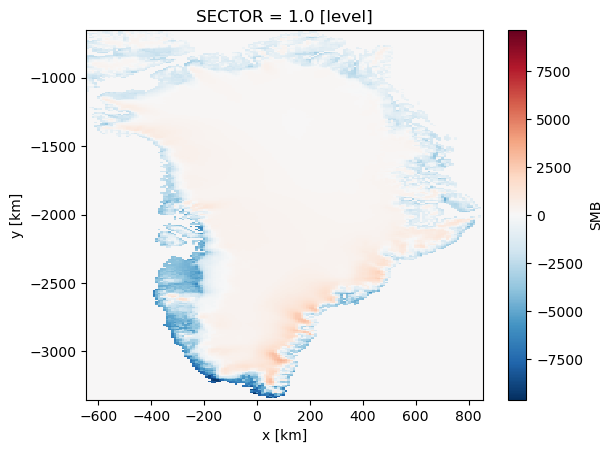

In [10]:
MAR_smb_yearly_mean_sel.plot();

In [11]:
# Select grid points that have <0 smb
fill_value = MAR_smb_yearly_mean_sel[0,0].values
MAR_ablation_mask_sel = xr.where(MAR_smb_yearly_mean_sel == fill_value, np.NaN, MAR_smb_yearly_mean_sel)
MAR_ablation_mask_sel = xr.where(MAR_ablation_mask_sel < 0, 1, 0)  #

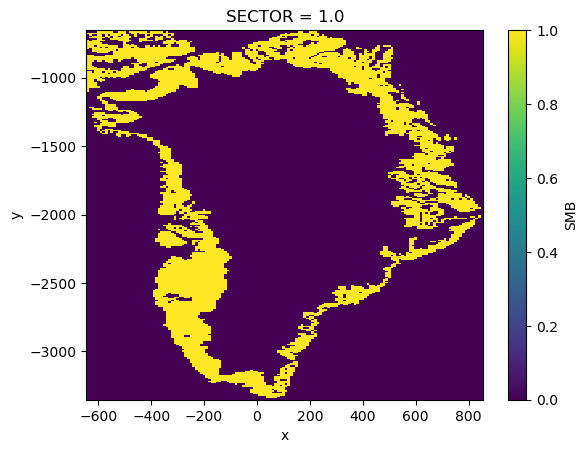

In [12]:
MAR_ablation_mask_sel.plot();

### Mask

#### MAR grid

In [13]:
#MAR_landmask = xr.open_dataset(home_dir+'data/RACMO/RACMO2.3p2_FGRN055/FGRN055_Masks.nc')['LSM_GR'] #Land sea mask (land:1, sea:0)
MAR_icemask = xr.open_dataset('/glade/derecho/scratch/ziqiyin/data/MAR/MARv3.14.0-10km-daily-ERA5-1940_2022.nc')['MSK'] #Ice mask
#MAR_icemask = xr.where(racmo_icemask==4, 1, 0)
#MAR_GrIS_mask = MAR_landmask * MAR_icemask # [only 0 or 1]
MAR_GrIS_mask = MAR_icemask/100

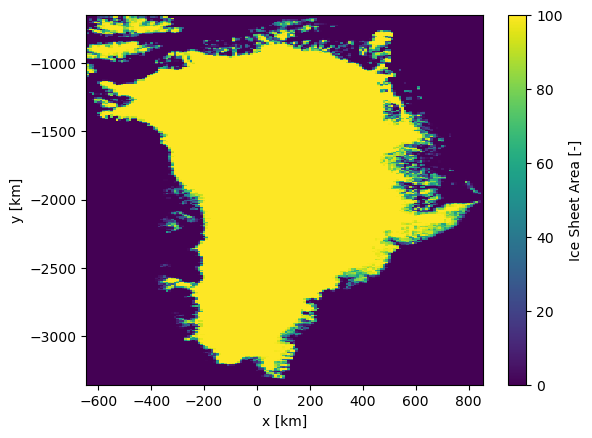

In [14]:
MAR_icemask.plot();

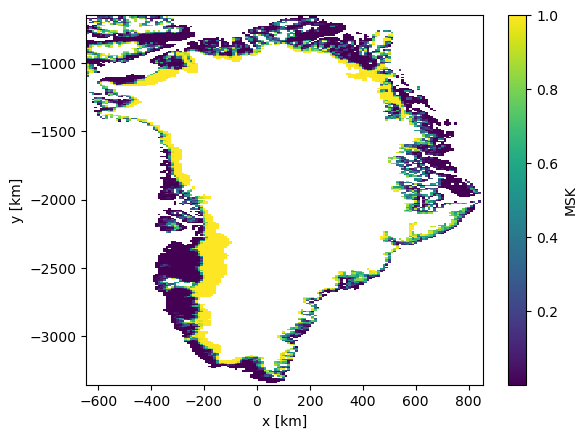

In [15]:
MAR_GrIS_ablation_mask = MAR_GrIS_mask * MAR_ablation_mask_sel.values
MAR_GrIS_ablation_mask.where(MAR_GrIS_ablation_mask>0).plot();

#### Regridded from RACMO

In [16]:
racmo_lon = xr.open_dataset(home_dir+'data/RACMO/RACMO2.3p2_FGRN055/snowmelt.1958-2022.BN_RACMO2.3p2_ERA5_3h_FGRN055.MM.nc')['lon'].values #[-180, 180]
racmo_lat = xr.open_dataset(home_dir+'data/RACMO/RACMO2.3p2_FGRN055/snowmelt.1958-2022.BN_RACMO2.3p2_ERA5_3h_FGRN055.MM.nc')['lat'].values

racmo_icemask = xr.open_dataset(home_dir+'data/RACMO/RACMO2.3p2_FGRN055/FGRN055_Masks.nc')['Promicemask'] #Ice mask(only ice sheet)
racmo_icemask = xr.where(racmo_icemask==4, 1, 0)

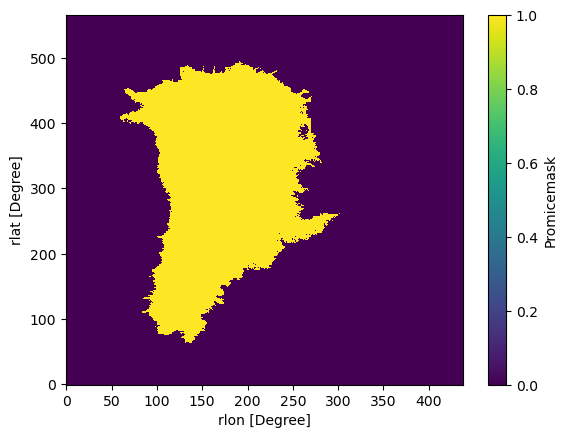

In [17]:
racmo_icemask.plot();

In [18]:
# RACMO
racmo_centers = np.stack((racmo_lon, racmo_lat))

# MAR
mar_centers = np.stack((mar_lon.values, mar_lat.values))

In [19]:
def regrid_grid_to_grid(centers_gridin, var_gridin, centers_gridout):

    # Input grid
    gridin = ESMF.Grid(np.array(var_gridin.T.shape), staggerloc=[ESMF.StaggerLoc.CENTER], coord_sys=ESMF.CoordSys.SPH_DEG)
    gridin_lon = gridin.get_coords(0, staggerloc=ESMF.StaggerLoc.CENTER)
    gridin_lat = gridin.get_coords(1, staggerloc=ESMF.StaggerLoc.CENTER)
    gridin_lon[...] = centers_gridin[0]
    gridin_lat[...] = centers_gridin[1]
    srcfield = ESMF.Field(gridin)
    srcfield.data[:] = var_gridin.T

    # Output grid
    gridout = ESMF.Grid(np.array(centers_gridout[0,:,:].shape), staggerloc=[ESMF.StaggerLoc.CENTER], coord_sys=ESMF.CoordSys.SPH_DEG)
    gridout_lon = gridout.get_coords(0, staggerloc=ESMF.StaggerLoc.CENTER)
    gridout_lat = gridout.get_coords(1, staggerloc=ESMF.StaggerLoc.CENTER)
    gridout_lon[...] = centers_gridout[0]
    gridout_lat[...] = centers_gridout[1]
    dstfield = ESMF.Field(gridout)
    dstfield.data[:] = 1e20

    # Compute the weight matrix for regridding
    regrid = ESMF.Regrid(srcfield, dstfield,
                          regrid_method=ESMF.RegridMethod.BILINEAR,
                          unmapped_action=ESMF.UnmappedAction.IGNORE)

    # Calculate the regridding from source to destination field
    outfield = regrid(srcfield, dstfield)
    outfield_data = outfield.data

    return outfield_data

In [20]:
racmo2mar_GrIS_mask = regrid_grid_to_grid(racmo_centers, racmo_icemask.T, mar_centers)

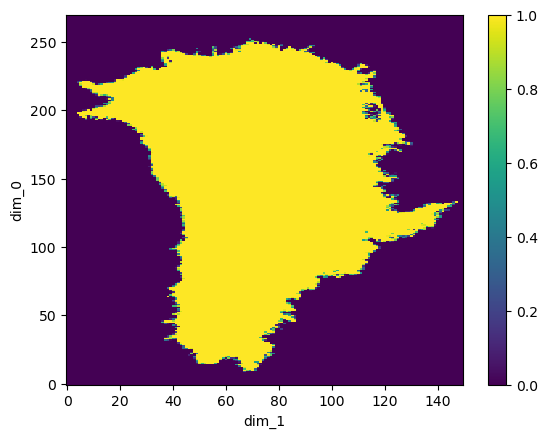

In [21]:
xr.DataArray(racmo2mar_GrIS_mask).plot(); # <1 values due to the bilinear method

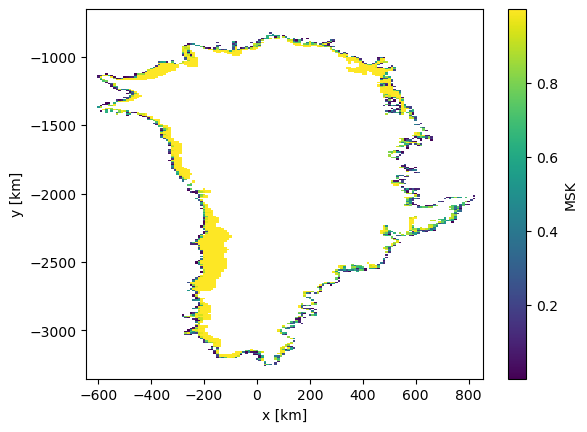

In [22]:
MAR_GrIS_ablation_mask = MAR_GrIS_ablation_mask * racmo2mar_GrIS_mask
MAR_GrIS_ablation_mask.where(MAR_GrIS_ablation_mask>0).plot();

## Calculate

In [23]:
#days_in_month = RACMO_melt_monthly_1940_2014.time.dt.days_in_month # [day]
MAR_GrIS_melt_daily_sel = (MAR_melt_daily_sel * MAR_GrIS_ablation_mask.values * MAR_area.values).sum(dim=['x','y']) / 1e3 # [m3/day]
MAR_GrIS_melt_daily_sel = MAR_GrIS_melt_daily_sel * 1e3 # [kg/day]

In [24]:
MAR_GrIS_melt_daily_sel_noleap = MAR_GrIS_melt_daily_sel.where((MAR_GrIS_melt_daily_sel.TIME.dt.date!=np.datetime64('1976-02-29'))
                                                                           & (MAR_GrIS_melt_daily_sel.TIME.dt.date!=np.datetime64('1980-02-29'))
                                                                           & (MAR_GrIS_melt_daily_sel.TIME.dt.date!=np.datetime64('1984-02-29'))
                                                                           & (MAR_GrIS_melt_daily_sel.TIME.dt.date!=np.datetime64('1988-02-29'))
                                                                           & (MAR_GrIS_melt_daily_sel.TIME.dt.date!=np.datetime64('1992-02-29'))
                                                                           & (MAR_GrIS_melt_daily_sel.TIME.dt.date!=np.datetime64('1996-02-29'))
                                                                           & (MAR_GrIS_melt_daily_sel.TIME.dt.date!=np.datetime64('2000-02-29'))
                                                                           & (MAR_GrIS_melt_daily_sel.TIME.dt.date!=np.datetime64('2004-02-29'))
                                                                           & (MAR_GrIS_melt_daily_sel.TIME.dt.date!=np.datetime64('2008-02-29'))
                                                                           & (MAR_GrIS_melt_daily_sel.TIME.dt.date!=np.datetime64('2012-02-29'))
                                                                           #& (MAR_GrIS_melt_daily_sel.TIME.dt.date!=np.datetime64('2016-02-29'))
                                                                           #& (MAR_GrIS_melt_daily_sel.TIME.dt.date!=np.datetime64('2020-02-29'))
                                                                           #& (MAR_GrIS_melt_daily_sel.TIME.dt.date!=np.datetime64('1940-02-29'))
                                                                           #& (MAR_GrIS_melt_daily_sel.TIME.dt.date!=np.datetime64('1944-02-29'))
                                                                           #& (MAR_GrIS_melt_daily_sel.TIME.dt.date!=np.datetime64('1948-02-29'))
                                                                           #& (MAR_GrIS_melt_daily_sel.TIME.dt.date!=np.datetime64('1952-02-29'))
                                                                           #& (MAR_GrIS_melt_daily_sel.TIME.dt.date!=np.datetime64('1956-02-29'))
                                                                           #& (MAR_GrIS_melt_daily_sel.TIME.dt.date!=np.datetime64('1960-02-29'))
                                                                           #& (MAR_GrIS_melt_daily_sel.TIME.dt.date!=np.datetime64('1964-02-29'))
                                                                           #& (MAR_GrIS_melt_daily_sel.TIME.dt.date!=np.datetime64('1968-02-29'))
                                                                           #& (MAR_GrIS_melt_daily_sel.TIME.dt.date!=np.datetime64('1972-02-29'))
                                                                           #& (MAR_GrIS_melt_daily_sel.TIME.dt.date!=np.datetime64('1976-02-29'))
                                                                           #& (MAR_GrIS_melt_daily_sel.TIME.dt.date!=np.datetime64('1980-02-29'))
                                                                           #& (MAR_GrIS_melt_daily_sel.TIME.dt.date!=np.datetime64('1984-02-29'))
                                                                           #& (MAR_GrIS_melt_daily_sel.TIME.dt.date!=np.datetime64('1988-02-29'))
                                                                           , drop=True)

In [25]:
# SEB
MAR_GrIS_SWn_daily_sel = (MAR_SWn_daily_sel * MAR_GrIS_ablation_mask.values * MAR_area.values).sum(dim=['x','y']) / (MAR_GrIS_ablation_mask * MAR_area.values).sum(dim=['x','y'])
MAR_GrIS_LWn_daily_sel = (MAR_LWn_daily_sel * MAR_GrIS_ablation_mask.values * MAR_area.values).sum(dim=['x','y']) / (MAR_GrIS_ablation_mask * MAR_area.values).sum(dim=['x','y'])
MAR_GrIS_SH_daily_sel = (MAR_SH_daily_sel * MAR_GrIS_ablation_mask.values * MAR_area.values).sum(dim=['x','y']) / (MAR_GrIS_ablation_mask * MAR_area.values).sum(dim=['x','y'])
MAR_GrIS_LH_daily_sel = (MAR_LH_daily_sel * MAR_GrIS_ablation_mask.values * MAR_area.values).sum(dim=['x','y']) / (MAR_GrIS_ablation_mask * MAR_area.values).sum(dim=['x','y'])

In [26]:
MAR_GrIS_SWn_daily_sel_noleap = MAR_GrIS_SWn_daily_sel.where((MAR_GrIS_SWn_daily_sel.TIME.dt.date!=np.datetime64('1976-02-29'))
                                                                           & (MAR_GrIS_SWn_daily_sel.TIME.dt.date!=np.datetime64('1980-02-29'))
                                                                           & (MAR_GrIS_SWn_daily_sel.TIME.dt.date!=np.datetime64('1984-02-29'))
                                                                           & (MAR_GrIS_SWn_daily_sel.TIME.dt.date!=np.datetime64('1988-02-29'))
                                                                           & (MAR_GrIS_SWn_daily_sel.TIME.dt.date!=np.datetime64('1992-02-29'))
                                                                           & (MAR_GrIS_SWn_daily_sel.TIME.dt.date!=np.datetime64('1996-02-29'))
                                                                           & (MAR_GrIS_SWn_daily_sel.TIME.dt.date!=np.datetime64('2000-02-29'))
                                                                           & (MAR_GrIS_SWn_daily_sel.TIME.dt.date!=np.datetime64('2004-02-29'))
                                                                           & (MAR_GrIS_SWn_daily_sel.TIME.dt.date!=np.datetime64('2008-02-29'))
                                                                           & (MAR_GrIS_SWn_daily_sel.TIME.dt.date!=np.datetime64('2012-02-29'))
                                                                           , drop=True)
MAR_GrIS_LWn_daily_sel_noleap = MAR_GrIS_LWn_daily_sel.where((MAR_GrIS_LWn_daily_sel.TIME.dt.date!=np.datetime64('1976-02-29'))
                                                                           & (MAR_GrIS_LWn_daily_sel.TIME.dt.date!=np.datetime64('1980-02-29'))
                                                                           & (MAR_GrIS_LWn_daily_sel.TIME.dt.date!=np.datetime64('1984-02-29'))
                                                                           & (MAR_GrIS_LWn_daily_sel.TIME.dt.date!=np.datetime64('1988-02-29'))
                                                                           & (MAR_GrIS_LWn_daily_sel.TIME.dt.date!=np.datetime64('1992-02-29'))
                                                                           & (MAR_GrIS_LWn_daily_sel.TIME.dt.date!=np.datetime64('1996-02-29'))
                                                                           & (MAR_GrIS_LWn_daily_sel.TIME.dt.date!=np.datetime64('2000-02-29'))
                                                                           & (MAR_GrIS_LWn_daily_sel.TIME.dt.date!=np.datetime64('2004-02-29'))
                                                                           & (MAR_GrIS_LWn_daily_sel.TIME.dt.date!=np.datetime64('2008-02-29'))
                                                                           & (MAR_GrIS_LWn_daily_sel.TIME.dt.date!=np.datetime64('2012-02-29'))
                                                                           , drop=True)
MAR_GrIS_SH_daily_sel_noleap = MAR_GrIS_SH_daily_sel.where((MAR_GrIS_SH_daily_sel.TIME.dt.date!=np.datetime64('1976-02-29'))
                                                                           & (MAR_GrIS_SH_daily_sel.TIME.dt.date!=np.datetime64('1980-02-29'))
                                                                           & (MAR_GrIS_SH_daily_sel.TIME.dt.date!=np.datetime64('1984-02-29'))
                                                                           & (MAR_GrIS_SH_daily_sel.TIME.dt.date!=np.datetime64('1988-02-29'))
                                                                           & (MAR_GrIS_SH_daily_sel.TIME.dt.date!=np.datetime64('1992-02-29'))
                                                                           & (MAR_GrIS_SH_daily_sel.TIME.dt.date!=np.datetime64('1996-02-29'))
                                                                           & (MAR_GrIS_SH_daily_sel.TIME.dt.date!=np.datetime64('2000-02-29'))
                                                                           & (MAR_GrIS_SH_daily_sel.TIME.dt.date!=np.datetime64('2004-02-29'))
                                                                           & (MAR_GrIS_SH_daily_sel.TIME.dt.date!=np.datetime64('2008-02-29'))
                                                                           & (MAR_GrIS_SH_daily_sel.TIME.dt.date!=np.datetime64('2012-02-29'))
                                                                           , drop=True)
MAR_GrIS_LH_daily_sel_noleap = MAR_GrIS_LH_daily_sel.where((MAR_GrIS_LH_daily_sel.TIME.dt.date!=np.datetime64('1976-02-29'))
                                                                           & (MAR_GrIS_LH_daily_sel.TIME.dt.date!=np.datetime64('1980-02-29'))
                                                                           & (MAR_GrIS_LH_daily_sel.TIME.dt.date!=np.datetime64('1984-02-29'))
                                                                           & (MAR_GrIS_LH_daily_sel.TIME.dt.date!=np.datetime64('1988-02-29'))
                                                                           & (MAR_GrIS_LH_daily_sel.TIME.dt.date!=np.datetime64('1992-02-29'))
                                                                           & (MAR_GrIS_LH_daily_sel.TIME.dt.date!=np.datetime64('1996-02-29'))
                                                                           & (MAR_GrIS_LH_daily_sel.TIME.dt.date!=np.datetime64('2000-02-29'))
                                                                           & (MAR_GrIS_LH_daily_sel.TIME.dt.date!=np.datetime64('2004-02-29'))
                                                                           & (MAR_GrIS_LH_daily_sel.TIME.dt.date!=np.datetime64('2008-02-29'))
                                                                           & (MAR_GrIS_LH_daily_sel.TIME.dt.date!=np.datetime64('2012-02-29'))
                                                                           , drop=True)

## Data pre-processing

In [27]:
time = xr.cftime_range(start="1975-01-01", periods=40*365, freq="D", calendar="noleap")

# --- Create xarray Dataset ---
ds = xr.Dataset(
    {
        "Melt": (("time",), MAR_GrIS_melt_daily_sel_noleap.values/1e12),  # [Gt/day]
        "SWn": (("time",), MAR_GrIS_SWn_daily_sel_noleap.values),  # [W/m2]
        "LWn": (("time",), MAR_GrIS_LWn_daily_sel_noleap.values),
        "SH": (("time",), MAR_GrIS_SH_daily_sel_noleap.values),
        "LH": (("time",), MAR_GrIS_LH_daily_sel_noleap.values),
    },
    coords={"time": time},
)

# --- Save to NetCDF file ---
ds.to_netcdf("MARv3.14.0_GrIS_ablation_daily_vars_1975_2014_mask_1975_2014.nc")

In [4]:
def process_prepare_pcmci(int_vars, remove_seasonal_cycle=True, add_mask=True, mask_period=np.arange(151,243)):

    # Stack arrays in sequence vertically (row wise)
    data = np.vstack((
        int_vars['Melt'].values,
        int_vars['SWn'].values,
        int_vars['LWn'].values,
        int_vars['SH'].values,
        int_vars['LH'].values,
                    )).T
    T, N = data.shape

    # Variable names used throughout
    var_names = ['Melt', 'SWn', 'LWn', 'SH', 'LH']

    # Smooth-width set to 15 years
    cycle_length = 365   # a year in monthly time resolution
    smooth_width = 15*cycle_length

    if smooth_width is not None:
        smoothdata_here = pp.smooth(np.copy(data), smooth_width=smooth_width, kernel='gaussian', # the low-frequency variability including the long-term trend
                        residuals=False)
        data_here = pp.smooth(np.copy(data), smooth_width=smooth_width, kernel='gaussian', # the detrended residuals or high-frequency variability
                        residuals=True)
    else:
        print("Not smoothed.")
        data_here = np.copy(data)

    # Remove seasonal mean and divide by seasonal standard deviation
    seasonal_cycle = anomalize(np.copy(data_here), cycle_length=cycle_length, return_cycle=True)
    smoothdata_here += seasonal_cycle # the sum of low-frequency variability and seasonal cycle
    if remove_seasonal_cycle == True:
        data_here = anomalize(data_here, cycle_length=cycle_length)

    # Construct mask to only select June to August
    if add_mask == True:
        mask = np.ones(data.shape, dtype='bool')
        for i in mask_period:
            mask[i::cycle_length, :] = False

    # Dataframe for raw data
    #raw_dataframe = pp.DataFrame(np.copy(data), mask=mask, var_names=var_names, datatime={0:np.arange(len(data))})
    # Dataframe for smoothed data
    #smoothdataframe_here = pp.DataFrame(smoothdata_here, var_names=var_names, datatime={0:np.arange(len(data))})
    # Initialize Tigramite dataframe (pre-processed data) with mask, missing_flag is not needed here
    dataframe = pp.DataFrame(data_here, mask=mask, var_names=var_names, missing_flag=999.)

    #data_smooth = data_here # for investigating data dependencies and lag functions

    robustparcorr = RobustParCorr(significance='analytic', mask_type='y')
    pcmci = PCMCI(
        dataframe=dataframe,
        cond_ind_test=robustparcorr,
        verbosity=0)

    return pcmci

## PCMCI+ causal discovery

Here, we choose ``tau_max=15`` for PCMCI. The other main parameter is ``pc_alpha`` which sets the significance level in the condition-selection step. The parameter ``alpha_level=0.05`` indicates that we threshold the resulting p-value matrix at this significance level to obtain the graph. 

Tigramite offers several plotting options: The lag function matrix (as shown above), the time series graph, and the process graph which aggregates the information in the time series graph. Both take as arguments the ``graph`` array and optionally the ``val_matrix`` and further link attributes.

In the process graph, the node color denotes the auto-MCI value and the link colors the cross-MCI value. If links occur at multiple lags between two variables, the link color denotes the strongest one and the label lists all significant lags in order of their strength. Additionally, setting ``show_autodependency_lags=True`` will display the significant auto dependencies below the respective node labels.

## Bootstrap

### cond_ind_test=robustparcorr, tau_max = 15

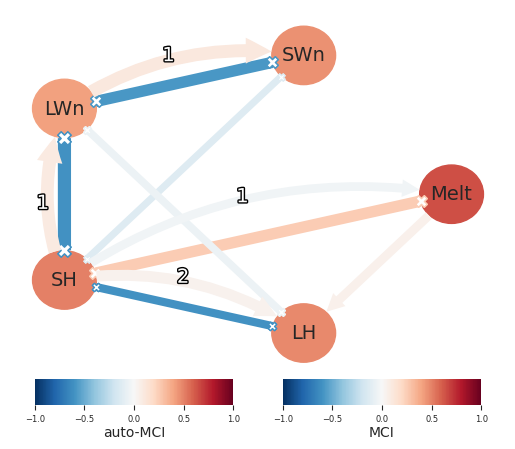

In [42]:
# alpha = 0.0025
pc_alpha_bootstrap = 0.0025
boot_samples = 100
tau_max = 15

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 1

## Create PCMCI object to call run_bootstrap_of
robustparcorr = RobustParCorr(significance='analytic')
pcmci = PCMCI(dataframe=dataframe,
        cond_ind_test=robustparcorr,
        verbosity=0,
        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=dataframe.var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/MAR/clean_mask/'
plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_SEB_MAR_noGHF_JJA_GrIS_ablation_1985_2014_daily_robustparcorr_conservative_nofdrc_alpha00025_taumax15.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [43]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=val_mat,
    graph=boot_graph,
    var_names=dataframe.var_names,
    link_width=boot_linkfreq,
    save_name=home_dir+'2023-GrIS-melt-causality/data/MAR/graph_pcmciplus_bootstrap_melt_SEB_MAR_noGHF_realJJA_GrIS_ablation_RACMOmask_1985_2014_daily_conservative_nofdrc_robustparcorr_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_clean.csv',
    digits=5,
)

In [44]:
save_name = home_dir+'2023-GrIS-melt-causality/data/MAR/graph_pcmciplus_bootstrap_melt_SEB_MAR_noGHF_realJJA_GrIS_ablation_RACMOmask_1985_2014_daily_conservative_nofdrc_robustparcorr_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_clean.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,Melt,1,-->,0.647100,1.00
1,Melt,Melt,2,-->,-0.130820,0.99
2,Melt,Melt,9,-->,0.035569,0.58
3,Melt,SH,0,x-x,0.256070,0.82
4,Melt,LH,0,-->,0.050278,0.64
5,SWn,SWn,1,-->,0.459040,1.00
6,SWn,SWn,2,-->,0.058262,0.99
7,SWn,LWn,0,x-x,-0.580150,0.82
8,SWn,SH,0,x-x,-0.131850,0.51
9,LWn,SWn,1,-->,0.102010,0.93


In [45]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/MAR/graph_pcmciplus_bootstrap_melt_SEB_MAR_noGHF_realJJA_GrIS_ablation_RACMOmask_1985_2014_daily_conservative_nofdrc_robustparcorr_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_clean_forplot.npz'

np.savez(save_name,
         val_matrix=val_mat,
         graph=boot_graph,
         link_width=boot_linkfreq,
         var_names=dataframe.var_names)

#### alpha = 0.005

##### Separate graphs for shorter periods

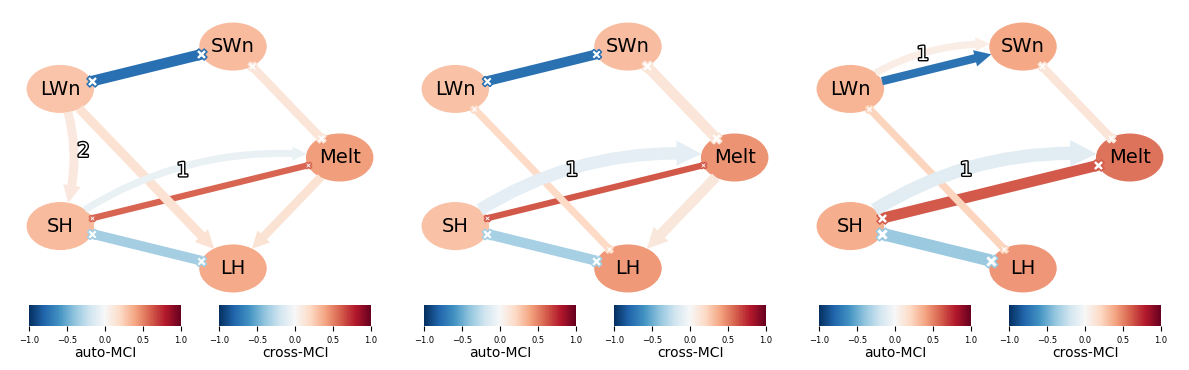

In [39]:
## Separate graphs
file = home_dir+'2023-GrIS-melt-causality/MAR/MARv3.14.0_GrIS_ablation_daily_vars_1975_2014_mask_1975_2014.nc'

# Define a 1x3 grid layout for 3 subplots
# without seasonality, alpha = 0.005
fig, axs = plt.subplots(1, 3, figsize=(12, 3.8))
axs = axs.flatten()  # Flatten to easily index subplots

pc_alpha_bootstrap = 0.005
boot_samples = 100
tau_max = 15

for n in range(3):
    if n == 0:
        int_vars = xr.open_dataset(file).sel(time=slice('1975-01-01','1994-12-31'))
    elif n == 1:
        int_vars = xr.open_dataset(file).sel(time=slice('1985-01-01','2004-12-31'))
    elif n == 2:
        int_vars = xr.open_dataset(file).sel(time=slice('1995-01-01','2014-12-31'))

    # The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
    # but its effect was not yet evaluated.
    boot_blocklength = 30

    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=True, add_mask=True, mask_period=np.arange(151,243))

    # Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments
    results = pcmci.run_bootstrap_of(
        method='run_pcmciplus',
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'},
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

    # Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
    boot_linkfreq = results['summary_results']['link_frequency']
    boot_graph = results['summary_results']['most_frequent_links']
    val_mat = results['summary_results']['val_matrix_mean']

    tp.plot_graph(
        graph = boot_graph,
        val_matrix= val_mat,
        link_width = boot_linkfreq,
        var_names=['Melt','SWn','LWn','SH','LH'],
        node_size=0.4,
        node_label_size=14,
        node_ticks=0.5,
        edge_ticks=0.5,
        link_label_fontsize=14,
        arrow_linewidth=10.0,
        link_colorbar_label='cross-MCI',
        node_colorbar_label='auto-MCI',
        fig_ax=(fig, axs[n])
        )

plt.tight_layout()
plot_dir = home_dir+'2023-GrIS-melt-causality/plot/MAR/clean_mask/1975_2014/'
plt.savefig(plot_dir+'graphs_pcmciplus_melt_SEB_noGHF_MAR_realJJA_GrIS_ablation_noseasonality_1975_2014_3p_conservative_nofdrc_robustparcorr_alpha'+str(pc_alpha_bootstrap)+'_taumax'+str(tau_max)+'_bbl'+str(boot_blocklength)+'.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

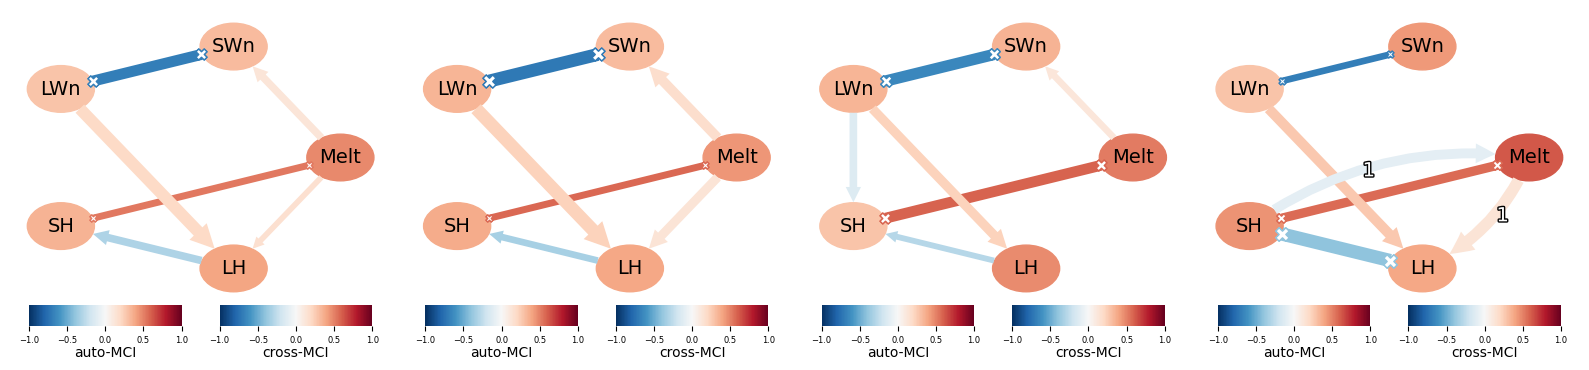

In [50]:
## Separate graphs
file = home_dir+'2023-GrIS-melt-causality/MAR/MARv3.14.0_GrIS_ablation_daily_vars_1975_2014_mask_1975_2014.nc'

# Define a 1x3 grid layout for 3 subplots
# without seasonality, alpha = 0.005
fig, axs = plt.subplots(1, 4, figsize=(16, 3.8))
axs = axs.flatten()  # Flatten to easily index subplots

pc_alpha_bootstrap = 0.005
boot_samples = 100
tau_max = 15

for n in range(4):
    if n == 0:
        int_vars = xr.open_dataset(file).sel(time=slice('1975-01-01','1984-12-31'))
    elif n == 1:
        int_vars = xr.open_dataset(file).sel(time=slice('1985-01-01','1994-12-31'))
    elif n == 2:
        int_vars = xr.open_dataset(file).sel(time=slice('1995-01-01','2004-12-31'))
    elif n == 3:
        int_vars = xr.open_dataset(file).sel(time=slice('2005-01-01','2014-12-31'))

    # The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
    # but its effect was not yet evaluated.
    boot_blocklength = 30

    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=True, add_mask=True, mask_period=np.arange(151,243))

    # Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments
    results = pcmci.run_bootstrap_of(
        method='run_pcmciplus',
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'},
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

    # Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
    boot_linkfreq = results['summary_results']['link_frequency']
    boot_graph = results['summary_results']['most_frequent_links']
    val_mat = results['summary_results']['val_matrix_mean']

    tp.plot_graph(
        graph = boot_graph,
        val_matrix= val_mat,
        link_width = boot_linkfreq,
        var_names=['Melt','SWn','LWn','SH','LH'],
        node_size=0.4,
        node_label_size=14,
        node_ticks=0.5,
        edge_ticks=0.5,
        link_label_fontsize=14,
        arrow_linewidth=10.0,
        link_colorbar_label='cross-MCI',
        node_colorbar_label='auto-MCI',
        fig_ax=(fig, axs[n])
        )

plt.tight_layout()
plot_dir = home_dir+'2023-GrIS-melt-causality/plot/MAR/clean_mask/1975_2014/'
plt.savefig(plot_dir+'graphs_pcmciplus_melt_SEB_noGHF_MAR_realJJA_GrIS_ablation_noseasonality_1975_2014_4p_conservative_nofdrc_robustparcorr_alpha'+str(pc_alpha_bootstrap)+'_taumax'+str(tau_max)+'_bbl'+str(boot_blocklength)+'.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

##### Summary graph for shorter periods

In [5]:
## Summary graph with most frequent link type
# --- settings ---
file = home_dir+'2023-GrIS-melt-causality/MAR/MARv3.14.0_GrIS_ablation_daily_vars_1975_2014_mask_1975_2014.nc'
variables = ['Melt','SWn','LWn','SH','LH']
num_vars = len(variables)

pc_alpha_bootstrap = 0.005
boot_samples = 100
tau_max = 15
boot_blocklength = 30
seed = 123

# Your real-JJA day-of-year mask (151..242)
mask_period = np.arange(151, 243)

period_slices = [
    ('1975-01-01','1984-12-31'),
    ('1985-01-01','1994-12-31'),
    ('1995-01-01','2004-12-31'),
    ('2005-01-01','2014-12-31')
]

# Storage: one entry per period
period_graphs = []      # boot_graph: (N, N, tau_max+1) strings
period_vals = []        # val_mat: (N, N, tau_max+1) float
period_linkfreqs = []   # boot_linkfreq: (N, N, tau_max+1) float

for (t0, t1) in period_slices:
    int_vars = xr.open_dataset(file).sel(time=slice(t0, t1))

    pcmci = process_prepare_pcmci(
        int_vars,
        remove_seasonal_cycle=True,
        add_mask=True,
        mask_period=mask_period
    )

    results = pcmci.run_bootstrap_of(
        method='run_pcmciplus',
        method_args={
            'tau_min': 0,
            'tau_max': tau_max,
            'pc_alpha': pc_alpha_bootstrap,
            'contemp_collider_rule': 'conservative'
        },
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=seed
    )

    boot_linkfreq = results['summary_results']['link_frequency']
    boot_graph    = results['summary_results']['most_frequent_links']
    val_mat       = results['summary_results']['val_matrix_mean']

    period_graphs.append(boot_graph)
    period_vals.append(val_mat)
    period_linkfreqs.append(boot_linkfreq)

# Convert to arrays for easier indexing:
# shapes:
#   graphs: (P, N, N, L)
#   vals  : (P, N, N, L)
#   freqs : (P, N, N, L)
graphs = np.stack(period_graphs, axis=0)
vals   = np.stack(period_vals, axis=0)
freqs  = np.stack(period_linkfreqs, axis=0)

P, N, _, L = graphs.shape
assert P == 4 and N == num_vars and L == tau_max + 1

In [6]:
# Output containers
summary_graph = np.full((N, N, L), '', dtype=graphs.dtype)
summary_val   = np.full((N, N, L), np.nan, dtype=float)
summary_width = np.zeros((N, N, L), dtype=float)

# Choose how to aggregate link widths across periods
# - 'mean' matches your "average strength" idea
# - 'sum' makes widths larger if the link is stable across more periods
width_agg = 'mean'   # change to 'sum' if you prefer

for tau in range(L):
    for i in range(N):
        for j in range(N):
            if i == j:
                # keep self-links as they come (you can also summarize them, see note below)
                continue

            types = list(graphs[:, i, j, tau])  # length P
            # Mode (most frequent). If ties, Counter returns one of them deterministically.
            mode_type, mode_count = Counter(types).most_common(1)[0]

            summary_graph[i, j, tau] = mode_type

            if mode_type == '' or mode_type is None:
                # No link most often -> leave val as NaN and width 0
                continue

            # Average val and width only over periods with that mode link type
            mask = (graphs[:, i, j, tau] == mode_type)

            # strength
            summary_val[i, j, tau] = np.nanmean(vals[mask, i, j, tau])

            # width
            if width_agg == 'mean':
                summary_width[i, j, tau] = np.nanmean(freqs[mask, i, j, tau])
            elif width_agg == 'sum':
                summary_width[i, j, tau] = np.nansum(freqs[mask, i, j, tau])
            else:
                raise ValueError("width_agg must be 'mean' or 'sum'")

In [7]:
node_self_vals = defaultdict(list)
node_self_sig  = defaultdict(list)

for p in range(P):
    g = graphs[p]
    v = vals[p]

    for i, var in enumerate(variables):
        self_series = v[i, i, 1:]  # tau=1..tau_max
        k = int(np.nanargmax(np.abs(self_series))) + 1
        max_val = float(np.nanmax(np.abs(self_series)))

        # Significant if the self-link type is not empty at that lag
        sig = (g[i, i, k] != '')

        node_self_vals[var].append(max_val)
        node_self_sig[var].append(sig)

# Majority rule across the 3 periods
summary_nodes = {}
for var in variables:
    sig_frac = np.mean(node_self_sig[var])
    summary_nodes[var] = np.mean(node_self_vals[var]) if sig_frac >= (2/4) else 0.0

node_colors = np.array([summary_nodes[v] for v in variables], dtype=float)

# Put node colors onto the diagonal at lag 1 for tp.plot_graph (your existing convention)
summary_val = summary_val.copy()
summary_graph = summary_graph.copy()
summary_val[np.arange(N), np.arange(N), 1] = node_colors
summary_graph[np.arange(N), np.arange(N), 1] = '-->'

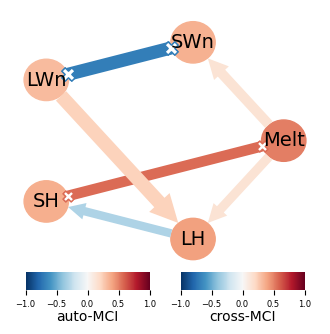

In [8]:
tp.plot_graph(
    graph=summary_graph,
    val_matrix=summary_val,
    link_width=summary_width,
    var_names=variables,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    figsize=(4, 3.4)
)

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/MAR/clean_mask/1975_2014/'
plt.savefig(
    plot_dir+f'graph_summary_mostfreq_across_4p_pcmciplus_MAR_realJJA_GrIS_ablation_noseasonality_1975_2014_conservative_alpha{pc_alpha_bootstrap}_taumax{tau_max}_bbl{boot_blocklength}_width{width_agg}.png',
    dpi=300, bbox_inches='tight', facecolor='w', transparent=False
)

In [9]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=summary_val,
    graph=summary_graph,
    var_names=variables,
    link_width=summary_width,
    save_name=home_dir+'2023-GrIS-melt-causality/data/MAR/graph_summary_mostfreq_across_4p_pcmciplus_bootstrap_melt_SEB_MAR_noGHF_realJJA_GrIS_ablation_RACMOmask_1975_2014_daily_conservative_nofdrc_robustparcorr_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv',
    digits=5,
)

In [10]:
save_name = home_dir+'2023-GrIS-melt-causality/data/MAR/graph_summary_mostfreq_across_4p_pcmciplus_bootstrap_melt_SEB_MAR_noGHF_realJJA_GrIS_ablation_RACMOmask_1975_2014_daily_conservative_nofdrc_robustparcorr_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,Melt,1,-->,0.51512,0.00000
1,Melt,SWn,0,-->,0.14320,0.57667
2,Melt,SH,0,x-x,0.56611,0.61250
3,Melt,LH,0,-->,0.14813,0.53000
4,SWn,SWn,1,-->,0.35219,0.00000
5,SWn,LWn,0,x-x,-0.69027,0.75500
6,LWn,LWn,1,-->,0.31396,0.00000
7,LWn,LH,0,-->,0.23205,0.79750
8,SH,SH,1,-->,0.36613,0.00000
9,SH,LH,0,<--,-0.30869,0.48333


In [11]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/MAR/graph_summary_mostfreq_across_4p_pcmciplus_bootstrap_melt_SEB_MAR_noGHF_realJJA_GrIS_ablation_RACMOmask_1975_2014_daily_conservative_nofdrc_robustparcorr_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean_forplot.npz'

np.savez(save_name,
        val_matrix=summary_val,
        graph=summary_graph,
        var_names=variables,
        link_width=summary_width)

#### alpha = 0.01

##### Single graph during the whole period

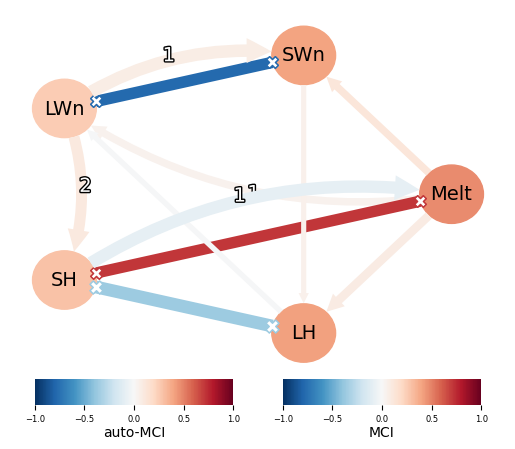

In [29]:
# alpha = 0.01
file = home_dir+'2023-GrIS-melt-causality/MAR/MARv3.14.0_GrIS_ablation_daily_vars_1975_2014_mask_1975_2014.nc'
int_vars = xr.open_dataset(file)

pc_alpha_bootstrap = 0.01
boot_samples = 100
tau_max = 15

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 30

## Create PCMCI object to call run_bootstrap_of
pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=True, add_mask=True, mask_period=np.arange(151,243))

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=['Melt','SWn','LWn','SH','LH'],
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/MAR/clean_mask/1975_2014/'
plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_SEB_MAR_noGHF_JJA_GrIS_ablation_1975_2014_daily_robustparcorr_conservative_nofdrc_alpha'+str(pc_alpha_bootstrap)+'_taumax'+str(tau_max)+'_bbl'+str(boot_blocklength)+'.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

##### Separate graphs for shorter periods

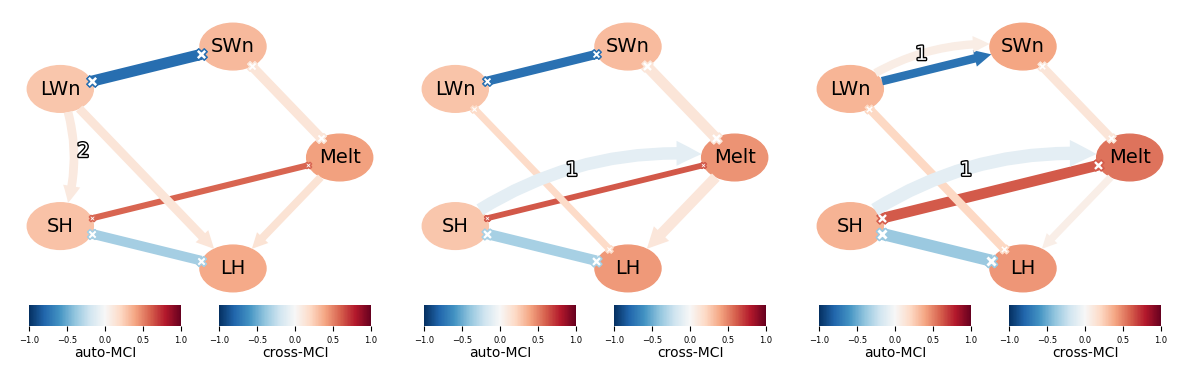

In [31]:
## Separate graphs
file = home_dir+'2023-GrIS-melt-causality/MAR/MARv3.14.0_GrIS_ablation_daily_vars_1975_2014_mask_1975_2014.nc'

# Define a 1x3 grid layout for 3 subplots
# without seasonality, alpha = 0.005
fig, axs = plt.subplots(1, 3, figsize=(12, 3.8))
axs = axs.flatten()  # Flatten to easily index subplots

pc_alpha_bootstrap = 0.01
boot_samples = 100
tau_max = 15

for n in range(3):
    if n == 0:
        int_vars = xr.open_dataset(file).sel(time=slice('1975-01-01','1994-12-31'))
    elif n == 1:
        int_vars = xr.open_dataset(file).sel(time=slice('1985-01-01','2004-12-31'))
    elif n == 2:
        int_vars = xr.open_dataset(file).sel(time=slice('1995-01-01','2014-12-31'))

    # The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
    # but its effect was not yet evaluated.
    boot_blocklength = 30

    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=True, add_mask=True, mask_period=np.arange(151,243))

    # Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments
    results = pcmci.run_bootstrap_of(
        method='run_pcmciplus',
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'},
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

    # Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
    boot_linkfreq = results['summary_results']['link_frequency']
    boot_graph = results['summary_results']['most_frequent_links']
    val_mat = results['summary_results']['val_matrix_mean']

    tp.plot_graph(
        graph = boot_graph,
        val_matrix= val_mat,
        link_width = boot_linkfreq,
        var_names=['Melt','SWn','LWn','SH','LH'],
        node_size=0.4,
        node_label_size=14,
        node_ticks=0.5,
        edge_ticks=0.5,
        link_label_fontsize=14,
        arrow_linewidth=10.0,
        link_colorbar_label='cross-MCI',
        node_colorbar_label='auto-MCI',
        fig_ax=(fig, axs[n])
        )

plt.tight_layout()
plot_dir = home_dir+'2023-GrIS-melt-causality/plot/MAR/clean_mask/1975_2014/'
plt.savefig(plot_dir+'graphs_pcmciplus_melt_SEB_noGHF_MAR_realJJA_GrIS_ablation_noseasonality_1975_2014_3p_conservative_nofdrc_robustparcorr_alpha'+str(pc_alpha_bootstrap)+'_taumax'+str(tau_max)+'_bbl'+str(boot_blocklength)+'.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

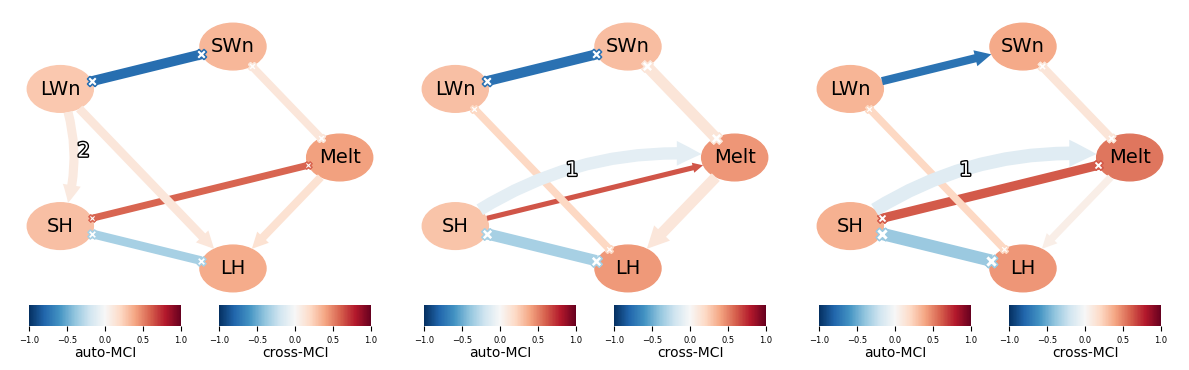

In [40]:
## Separate graphs (boot_blocklength = 15)
file = home_dir+'2023-GrIS-melt-causality/MAR/MARv3.14.0_GrIS_ablation_daily_vars_1975_2014_mask_1975_2014.nc'

# Define a 1x3 grid layout for 3 subplots
# without seasonality, alpha = 0.005
fig, axs = plt.subplots(1, 3, figsize=(12, 3.8))
axs = axs.flatten()  # Flatten to easily index subplots

pc_alpha_bootstrap = 0.01
boot_samples = 100
tau_max = 15

for n in range(3):
    if n == 0:
        int_vars = xr.open_dataset(file).sel(time=slice('1975-01-01','1994-12-31'))
    elif n == 1:
        int_vars = xr.open_dataset(file).sel(time=slice('1985-01-01','2004-12-31'))
    elif n == 2:
        int_vars = xr.open_dataset(file).sel(time=slice('1995-01-01','2014-12-31'))

    # The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
    # but its effect was not yet evaluated.
    boot_blocklength = 15

    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=True, add_mask=True, mask_period=np.arange(151,243))

    # Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments
    results = pcmci.run_bootstrap_of(
        method='run_pcmciplus',
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'},
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

    # Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
    boot_linkfreq = results['summary_results']['link_frequency']
    boot_graph = results['summary_results']['most_frequent_links']
    val_mat = results['summary_results']['val_matrix_mean']

    tp.plot_graph(
        graph = boot_graph,
        val_matrix= val_mat,
        link_width = boot_linkfreq,
        var_names=['Melt','SWn','LWn','SH','LH'],
        node_size=0.4,
        node_label_size=14,
        node_ticks=0.5,
        edge_ticks=0.5,
        link_label_fontsize=14,
        arrow_linewidth=10.0,
        link_colorbar_label='cross-MCI',
        node_colorbar_label='auto-MCI',
        fig_ax=(fig, axs[n])
        )

plt.tight_layout()
plot_dir = home_dir+'2023-GrIS-melt-causality/plot/MAR/clean_mask/1975_2014/'
plt.savefig(plot_dir+'graphs_pcmciplus_melt_SEB_noGHF_MAR_realJJA_GrIS_ablation_noseasonality_1975_2014_3p_conservative_nofdrc_robustparcorr_alpha'+str(pc_alpha_bootstrap)+'_taumax'+str(tau_max)+'_bbl'+str(boot_blocklength)+'.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

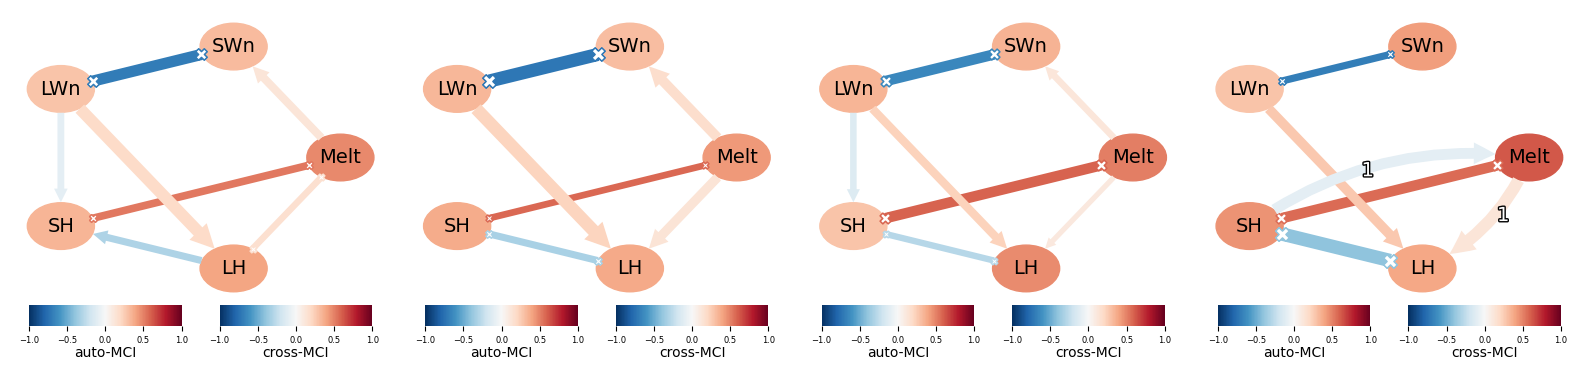

In [42]:
## Separate graphs
file = home_dir+'2023-GrIS-melt-causality/MAR/MARv3.14.0_GrIS_ablation_daily_vars_1975_2014_mask_1975_2014.nc'

# Define a 1x3 grid layout for 3 subplots
# without seasonality, alpha = 0.005
fig, axs = plt.subplots(1, 4, figsize=(16, 3.8))
axs = axs.flatten()  # Flatten to easily index subplots

pc_alpha_bootstrap = 0.01
boot_samples = 100
tau_max = 15

for n in range(4):
    if n == 0:
        int_vars = xr.open_dataset(file).sel(time=slice('1975-01-01','1984-12-31'))
    elif n == 1:
        int_vars = xr.open_dataset(file).sel(time=slice('1985-01-01','1994-12-31'))
    elif n == 2:
        int_vars = xr.open_dataset(file).sel(time=slice('1995-01-01','2004-12-31'))
    elif n == 3:
        int_vars = xr.open_dataset(file).sel(time=slice('2005-01-01','2014-12-31'))

    # The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
    # but its effect was not yet evaluated.
    boot_blocklength = 30

    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=True, add_mask=True, mask_period=np.arange(151,243))

    # Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments
    results = pcmci.run_bootstrap_of(
        method='run_pcmciplus',
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'},
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

    # Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
    boot_linkfreq = results['summary_results']['link_frequency']
    boot_graph = results['summary_results']['most_frequent_links']
    val_mat = results['summary_results']['val_matrix_mean']

    tp.plot_graph(
        graph = boot_graph,
        val_matrix= val_mat,
        link_width = boot_linkfreq,
        var_names=['Melt','SWn','LWn','SH','LH'],
        node_size=0.4,
        node_label_size=14,
        node_ticks=0.5,
        edge_ticks=0.5,
        link_label_fontsize=14,
        arrow_linewidth=10.0,
        link_colorbar_label='cross-MCI',
        node_colorbar_label='auto-MCI',
        fig_ax=(fig, axs[n])
        )

plt.tight_layout()
plot_dir = home_dir+'2023-GrIS-melt-causality/plot/MAR/clean_mask/1975_2014/'
plt.savefig(plot_dir+'graphs_pcmciplus_melt_SEB_noGHF_MAR_realJJA_GrIS_ablation_noseasonality_1975_2014_4p_conservative_nofdrc_robustparcorr_alpha'+str(pc_alpha_bootstrap)+'_taumax'+str(tau_max)+'_bbl'+str(boot_blocklength)+'.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

##### Summary graph for shorter periods

In [32]:
## Summary graph with most frequent link type
# --- settings ---
file = home_dir+'2023-GrIS-melt-causality/MAR/MARv3.14.0_GrIS_ablation_daily_vars_1975_2014_mask_1975_2014.nc'
variables = ['Melt','SWn','LWn','SH','LH']
num_vars = len(variables)

pc_alpha_bootstrap = 0.01
boot_samples = 100
tau_max = 15
boot_blocklength = 30
seed = 123

# Your real-JJA day-of-year mask (151..242)
mask_period = np.arange(151, 243)

period_slices = [
    ('1975-01-01','1994-12-31'),
    ('1985-01-01','2004-12-31'),
    ('1995-01-01','2014-12-31')
]

# Storage: one entry per period
period_graphs = []      # boot_graph: (N, N, tau_max+1) strings
period_vals = []        # val_mat: (N, N, tau_max+1) float
period_linkfreqs = []   # boot_linkfreq: (N, N, tau_max+1) float

for (t0, t1) in period_slices:
    int_vars = xr.open_dataset(file).sel(time=slice(t0, t1))

    pcmci = process_prepare_pcmci(
        int_vars,
        remove_seasonal_cycle=True,
        add_mask=True,
        mask_period=mask_period
    )

    results = pcmci.run_bootstrap_of(
        method='run_pcmciplus',
        method_args={
            'tau_min': 0,
            'tau_max': tau_max,
            'pc_alpha': pc_alpha_bootstrap,
            'contemp_collider_rule': 'conservative'
        },
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=seed
    )

    boot_linkfreq = results['summary_results']['link_frequency']
    boot_graph    = results['summary_results']['most_frequent_links']
    val_mat       = results['summary_results']['val_matrix_mean']

    period_graphs.append(boot_graph)
    period_vals.append(val_mat)
    period_linkfreqs.append(boot_linkfreq)

# Convert to arrays for easier indexing:
# shapes:
#   graphs: (P, N, N, L)
#   vals  : (P, N, N, L)
#   freqs : (P, N, N, L)
graphs = np.stack(period_graphs, axis=0)
vals   = np.stack(period_vals, axis=0)
freqs  = np.stack(period_linkfreqs, axis=0)

P, N, _, L = graphs.shape
assert P == 3 and N == num_vars and L == tau_max + 1

In [33]:
# Output containers
summary_graph = np.full((N, N, L), '', dtype=graphs.dtype)
summary_val   = np.full((N, N, L), np.nan, dtype=float)
summary_width = np.zeros((N, N, L), dtype=float)

# Choose how to aggregate link widths across periods
# - 'mean' matches your "average strength" idea
# - 'sum' makes widths larger if the link is stable across more periods
width_agg = 'mean'   # change to 'sum' if you prefer

for tau in range(L):
    for i in range(N):
        for j in range(N):
            if i == j:
                # keep self-links as they come (you can also summarize them, see note below)
                continue

            types = list(graphs[:, i, j, tau])  # length P
            # Mode (most frequent). If ties, Counter returns one of them deterministically.
            mode_type, mode_count = Counter(types).most_common(1)[0]

            summary_graph[i, j, tau] = mode_type

            if mode_type == '' or mode_type is None:
                # No link most often -> leave val as NaN and width 0
                continue

            # Average val and width only over periods with that mode link type
            mask = (graphs[:, i, j, tau] == mode_type)

            # strength
            summary_val[i, j, tau] = np.nanmean(vals[mask, i, j, tau])

            # width
            if width_agg == 'mean':
                summary_width[i, j, tau] = np.nanmean(freqs[mask, i, j, tau])
            elif width_agg == 'sum':
                summary_width[i, j, tau] = np.nansum(freqs[mask, i, j, tau])
            else:
                raise ValueError("width_agg must be 'mean' or 'sum'")

In [34]:
node_self_vals = defaultdict(list)
node_self_sig  = defaultdict(list)

for p in range(P):
    g = graphs[p]
    v = vals[p]

    for i, var in enumerate(variables):
        self_series = v[i, i, 1:]  # tau=1..tau_max
        k = int(np.nanargmax(np.abs(self_series))) + 1
        max_val = float(np.nanmax(np.abs(self_series)))

        # Significant if the self-link type is not empty at that lag
        sig = (g[i, i, k] != '')

        node_self_vals[var].append(max_val)
        node_self_sig[var].append(sig)

# Majority rule across the 3 periods
summary_nodes = {}
for var in variables:
    sig_frac = np.mean(node_self_sig[var])
    summary_nodes[var] = np.mean(node_self_vals[var]) if sig_frac >= (2/3) else 0.0

node_colors = np.array([summary_nodes[v] for v in variables], dtype=float)

# Put node colors onto the diagonal at lag 1 for tp.plot_graph (your existing convention)
summary_val = summary_val.copy()
summary_graph = summary_graph.copy()
summary_val[np.arange(N), np.arange(N), 1] = node_colors
summary_graph[np.arange(N), np.arange(N), 1] = '-->'

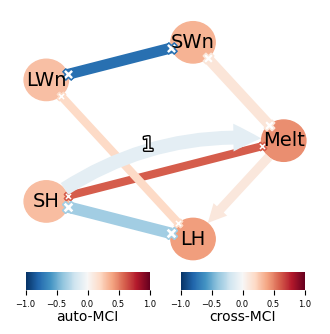

In [35]:
tp.plot_graph(
    graph=summary_graph,
    val_matrix=summary_val,
    link_width=summary_width,
    var_names=variables,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    figsize=(4, 3.4)
)

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/MAR/clean_mask/1975_2014/'
plt.savefig(
    plot_dir+f'graph_summary_mostfreq_across_3p_pcmciplus_MAR_realJJA_GrIS_ablation_noseasonality_1975_2014_conservative_alpha{pc_alpha_bootstrap}_taumax{tau_max}_bbl{boot_blocklength}_width{width_agg}.png',
    dpi=300, bbox_inches='tight', facecolor='w', transparent=False
)

In [36]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=summary_val,
    graph=summary_graph,
    var_names=variables,
    link_width=summary_width,
    save_name=home_dir+'2023-GrIS-melt-causality/data/MAR/graph_summary_mostfreq_across_3p_pcmciplus_bootstrap_melt_SEB_MAR_noGHF_realJJA_GrIS_ablation_RACMOmask_1975_2014_daily_conservative_nofdrc_robustparcorr_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv',
    digits=5,
)

In [37]:
save_name = home_dir+'2023-GrIS-melt-causality/data/MAR/graph_summary_mostfreq_across_3p_pcmciplus_bootstrap_melt_SEB_MAR_noGHF_realJJA_GrIS_ablation_RACMOmask_1975_2014_daily_conservative_nofdrc_robustparcorr_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,Melt,1,-->,0.465130,0.00000
1,Melt,SWn,0,x-x,0.127660,0.69000
2,Melt,SH,0,x-x,0.605870,0.54333
3,Melt,LH,0,-->,0.110600,0.61667
4,SWn,SWn,1,-->,0.344460,0.00000
5,SWn,LWn,0,x-x,-0.752660,0.73000
6,LWn,LWn,1,-->,0.301260,0.00000
7,LWn,LH,0,x-x,0.201470,0.55000
8,SH,Melt,1,-->,-0.097414,0.93000
9,SH,SH,1,-->,0.308250,0.00000


In [38]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/MAR/graph_summary_mostfreq_across_3p_pcmciplus_bootstrap_melt_SEB_MAR_noGHF_realJJA_GrIS_ablation_RACMOmask_1975_2014_daily_conservative_nofdrc_robustparcorr_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean_forplot.npz'

np.savez(save_name,
        val_matrix=summary_val,
        graph=summary_graph,
        var_names=variables,
        link_width=summary_width)

##### Summary graph for shorter periods

In [43]:
## Summary graph with most frequent link type
# --- settings ---
file = home_dir+'2023-GrIS-melt-causality/MAR/MARv3.14.0_GrIS_ablation_daily_vars_1975_2014_mask_1975_2014.nc'
variables = ['Melt','SWn','LWn','SH','LH']
num_vars = len(variables)

pc_alpha_bootstrap = 0.01
boot_samples = 100
tau_max = 15
boot_blocklength = 30
seed = 123

# Your real-JJA day-of-year mask (151..242)
mask_period = np.arange(151, 243)

period_slices = [
    ('1975-01-01','1984-12-31'),
    ('1985-01-01','1994-12-31'),
    ('1995-01-01','2004-12-31'),
    ('2005-01-01','2014-12-31')
]

# Storage: one entry per period
period_graphs = []      # boot_graph: (N, N, tau_max+1) strings
period_vals = []        # val_mat: (N, N, tau_max+1) float
period_linkfreqs = []   # boot_linkfreq: (N, N, tau_max+1) float

for (t0, t1) in period_slices:
    int_vars = xr.open_dataset(file).sel(time=slice(t0, t1))

    pcmci = process_prepare_pcmci(
        int_vars,
        remove_seasonal_cycle=True,
        add_mask=True,
        mask_period=mask_period
    )

    results = pcmci.run_bootstrap_of(
        method='run_pcmciplus',
        method_args={
            'tau_min': 0,
            'tau_max': tau_max,
            'pc_alpha': pc_alpha_bootstrap,
            'contemp_collider_rule': 'conservative'
        },
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=seed
    )

    boot_linkfreq = results['summary_results']['link_frequency']
    boot_graph    = results['summary_results']['most_frequent_links']
    val_mat       = results['summary_results']['val_matrix_mean']

    period_graphs.append(boot_graph)
    period_vals.append(val_mat)
    period_linkfreqs.append(boot_linkfreq)

# Convert to arrays for easier indexing:
# shapes:
#   graphs: (P, N, N, L)
#   vals  : (P, N, N, L)
#   freqs : (P, N, N, L)
graphs = np.stack(period_graphs, axis=0)
vals   = np.stack(period_vals, axis=0)
freqs  = np.stack(period_linkfreqs, axis=0)

P, N, _, L = graphs.shape
assert P == 4 and N == num_vars and L == tau_max + 1

In [44]:
# Output containers
summary_graph = np.full((N, N, L), '', dtype=graphs.dtype)
summary_val   = np.full((N, N, L), np.nan, dtype=float)
summary_width = np.zeros((N, N, L), dtype=float)

# Choose how to aggregate link widths across periods
# - 'mean' matches your "average strength" idea
# - 'sum' makes widths larger if the link is stable across more periods
width_agg = 'mean'   # change to 'sum' if you prefer

for tau in range(L):
    for i in range(N):
        for j in range(N):
            if i == j:
                # keep self-links as they come (you can also summarize them, see note below)
                continue

            types = list(graphs[:, i, j, tau])  # length P
            # Mode (most frequent). If ties, Counter returns one of them deterministically.
            mode_type, mode_count = Counter(types).most_common(1)[0]

            summary_graph[i, j, tau] = mode_type

            if mode_type == '' or mode_type is None:
                # No link most often -> leave val as NaN and width 0
                continue

            # Average val and width only over periods with that mode link type
            mask = (graphs[:, i, j, tau] == mode_type)

            # strength
            summary_val[i, j, tau] = np.nanmean(vals[mask, i, j, tau])

            # width
            if width_agg == 'mean':
                summary_width[i, j, tau] = np.nanmean(freqs[mask, i, j, tau])
            elif width_agg == 'sum':
                summary_width[i, j, tau] = np.nansum(freqs[mask, i, j, tau])
            else:
                raise ValueError("width_agg must be 'mean' or 'sum'")

In [45]:
node_self_vals = defaultdict(list)
node_self_sig  = defaultdict(list)

for p in range(P):
    g = graphs[p]
    v = vals[p]

    for i, var in enumerate(variables):
        self_series = v[i, i, 1:]  # tau=1..tau_max
        k = int(np.nanargmax(np.abs(self_series))) + 1
        max_val = float(np.nanmax(np.abs(self_series)))

        # Significant if the self-link type is not empty at that lag
        sig = (g[i, i, k] != '')

        node_self_vals[var].append(max_val)
        node_self_sig[var].append(sig)

# Majority rule across the 4 periods
summary_nodes = {}
for var in variables:
    sig_frac = np.mean(node_self_sig[var])
    summary_nodes[var] = np.mean(node_self_vals[var]) if sig_frac >= (2/4) else 0.0

node_colors = np.array([summary_nodes[v] for v in variables], dtype=float)

# Put node colors onto the diagonal at lag 1 for tp.plot_graph (your existing convention)
summary_val = summary_val.copy()
summary_graph = summary_graph.copy()
summary_val[np.arange(N), np.arange(N), 1] = node_colors
summary_graph[np.arange(N), np.arange(N), 1] = '-->'

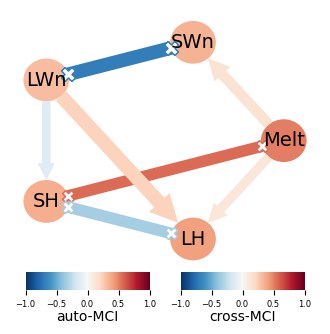

In [46]:
tp.plot_graph(
    graph=summary_graph,
    val_matrix=summary_val,
    link_width=summary_width,
    var_names=variables,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    figsize=(4, 3.4)
)

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/MAR/clean_mask/1975_2014/'
plt.savefig(
    plot_dir+f'graph_summary_mostfreq_across_4p_pcmciplus_MAR_realJJA_GrIS_ablation_noseasonality_1975_2014_conservative_alpha{pc_alpha_bootstrap}_taumax{tau_max}_bbl{boot_blocklength}_width{width_agg}.png',
    dpi=300, bbox_inches='tight', facecolor='w', transparent=False
)

In [47]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=summary_val,
    graph=summary_graph,
    var_names=variables,
    link_width=summary_width,
    save_name=home_dir+'2023-GrIS-melt-causality/data/MAR/graph_summary_mostfreq_across_4p_pcmciplus_bootstrap_melt_SEB_MAR_noGHF_realJJA_GrIS_ablation_RACMOmask_1975_2014_daily_conservative_nofdrc_robustparcorr_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv',
    digits=5,
)

In [48]:
save_name = home_dir+'2023-GrIS-melt-causality/data/MAR/graph_summary_mostfreq_across_4p_pcmciplus_bootstrap_melt_SEB_MAR_noGHF_realJJA_GrIS_ablation_RACMOmask_1975_2014_daily_conservative_nofdrc_robustparcorr_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,Melt,1,-->,0.50994,0.00000
1,Melt,SWn,0,-->,0.14171,0.59333
2,Melt,SH,0,x-x,0.56626,0.63750
3,Melt,LH,0,-->,0.12057,0.52500
4,SWn,SWn,1,-->,0.34669,0.00000
5,SWn,LWn,0,x-x,-0.69182,0.76000
6,LWn,LWn,1,-->,0.30905,0.00000
7,LWn,SH,0,-->,-0.11755,0.48000
8,LWn,LH,0,-->,0.22691,0.76750
9,SH,SH,1,-->,0.36066,0.00000


In [49]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/MAR/graph_summary_mostfreq_across_4p_pcmciplus_bootstrap_melt_SEB_MAR_noGHF_realJJA_GrIS_ablation_RACMOmask_1975_2014_daily_conservative_nofdrc_robustparcorr_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean_forplot.npz'

np.savez(save_name,
        val_matrix=summary_val,
        graph=summary_graph,
        var_names=variables,
        link_width=summary_width)

#### alpha = 0.025

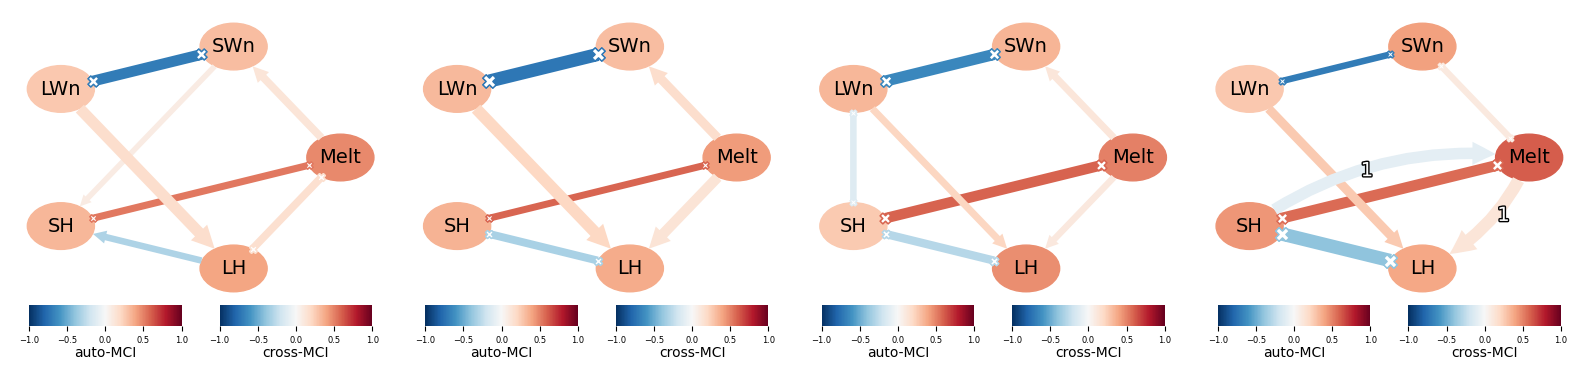

In [5]:
## Separate graphs
file = home_dir+'2023-GrIS-melt-causality/MAR/MARv3.14.0_GrIS_ablation_daily_vars_1975_2014_mask_1975_2014.nc'

# Define a 1x3 grid layout for 3 subplots
# without seasonality, alpha = 0.005
fig, axs = plt.subplots(1, 4, figsize=(16, 3.8))
axs = axs.flatten()  # Flatten to easily index subplots

pc_alpha_bootstrap = 0.025
boot_samples = 100
tau_max = 15

for n in range(4):
    if n == 0:
        int_vars = xr.open_dataset(file).sel(time=slice('1975-01-01','1984-12-31'))
    elif n == 1:
        int_vars = xr.open_dataset(file).sel(time=slice('1985-01-01','1994-12-31'))
    elif n == 2:
        int_vars = xr.open_dataset(file).sel(time=slice('1995-01-01','2004-12-31'))
    elif n == 3:
        int_vars = xr.open_dataset(file).sel(time=slice('2005-01-01','2014-12-31'))

    # The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
    # but its effect was not yet evaluated.
    boot_blocklength = 30

    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=True, add_mask=True, mask_period=np.arange(151,243))

    # Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments
    results = pcmci.run_bootstrap_of(
        method='run_pcmciplus',
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'},
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

    # Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
    boot_linkfreq = results['summary_results']['link_frequency']
    boot_graph = results['summary_results']['most_frequent_links']
    val_mat = results['summary_results']['val_matrix_mean']

    tp.plot_graph(
        graph = boot_graph,
        val_matrix= val_mat,
        link_width = boot_linkfreq,
        var_names=['Melt','SWn','LWn','SH','LH'],
        node_size=0.4,
        node_label_size=14,
        node_ticks=0.5,
        edge_ticks=0.5,
        link_label_fontsize=14,
        arrow_linewidth=10.0,
        link_colorbar_label='cross-MCI',
        node_colorbar_label='auto-MCI',
        fig_ax=(fig, axs[n])
        )

plt.tight_layout()
plot_dir = home_dir+'2023-GrIS-melt-causality/plot/MAR/clean_mask/1975_2014/'
plt.savefig(plot_dir+'graphs_pcmciplus_melt_SEB_noGHF_MAR_realJJA_GrIS_ablation_noseasonality_1975_2014_4p_conservative_nofdrc_robustparcorr_alpha'+str(pc_alpha_bootstrap)+'_taumax'+str(tau_max)+'_bbl'+str(boot_blocklength)+'.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [6]:
## Summary graph with most frequent link type
# --- settings ---
file = home_dir+'2023-GrIS-melt-causality/MAR/MARv3.14.0_GrIS_ablation_daily_vars_1975_2014_mask_1975_2014.nc'
variables = ['Melt','SWn','LWn','SH','LH']
num_vars = len(variables)

pc_alpha_bootstrap = 0.025
boot_samples = 100
tau_max = 15
boot_blocklength = 30
seed = 123

# Your real-JJA day-of-year mask (151..242)
mask_period = np.arange(151, 243)

period_slices = [
    ('1975-01-01','1984-12-31'),
    ('1985-01-01','1994-12-31'),
    ('1995-01-01','2004-12-31'),
    ('2005-01-01','2014-12-31')
]

# Storage: one entry per period
period_graphs = []      # boot_graph: (N, N, tau_max+1) strings
period_vals = []        # val_mat: (N, N, tau_max+1) float
period_linkfreqs = []   # boot_linkfreq: (N, N, tau_max+1) float

for (t0, t1) in period_slices:
    int_vars = xr.open_dataset(file).sel(time=slice(t0, t1))

    pcmci = process_prepare_pcmci(
        int_vars,
        remove_seasonal_cycle=True,
        add_mask=True,
        mask_period=mask_period
    )

    results = pcmci.run_bootstrap_of(
        method='run_pcmciplus',
        method_args={
            'tau_min': 0,
            'tau_max': tau_max,
            'pc_alpha': pc_alpha_bootstrap,
            'contemp_collider_rule': 'conservative'
        },
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=seed
    )

    boot_linkfreq = results['summary_results']['link_frequency']
    boot_graph    = results['summary_results']['most_frequent_links']
    val_mat       = results['summary_results']['val_matrix_mean']

    period_graphs.append(boot_graph)
    period_vals.append(val_mat)
    period_linkfreqs.append(boot_linkfreq)

# Convert to arrays for easier indexing:
# shapes:
#   graphs: (P, N, N, L)
#   vals  : (P, N, N, L)
#   freqs : (P, N, N, L)
graphs = np.stack(period_graphs, axis=0)
vals   = np.stack(period_vals, axis=0)
freqs  = np.stack(period_linkfreqs, axis=0)

P, N, _, L = graphs.shape
assert P == 4 and N == num_vars and L == tau_max + 1

In [7]:
def is_directed_link(t: str) -> bool:
    """
    Treat any link containing an arrow head/tail (< or >) as 'directed/partly-directed'.
    Undirected/no-link examples: '', 'o-o', 'x-x' (and None).
    """
    if t is None or t in ['', 'o-o', 'x-x']:
        return False
    return ('<' in t) or ('>' in t)

def choose_mode_with_directed_tiebreak(types, vals_for_types=None):
    """
    Pick the most frequent type. If tie (e.g., 2 vs 2), prefer directed over undirected.
    If still tied, optionally break tie by larger mean |val| (if vals_for_types provided),
    otherwise fall back to deterministic sorting.
    """
    c = Counter(types)
    max_count = max(c.values())
    candidates = [t for t, cnt in c.items() if cnt == max_count]

    # tie-break 1: prefer directed (includes partly-directed like o->, <-o, etc.)
    directed = [t for t in candidates if is_directed_link(t)]
    if directed:
        candidates = directed

    # tie-break 2 (optional): stronger mean absolute val among candidates
    if vals_for_types is not None:
        def mean_abs_val(t):
            vv = [abs(v) for tt, v in zip(types, vals_for_types) if tt == t and not np.isnan(v)]
            return np.mean(vv) if len(vv) else -np.inf
        chosen = max(candidates, key=mean_abs_val)
    else:
        # deterministic fallback
        chosen = sorted([str(t) for t in candidates])[0]

    return chosen, max_count

In [8]:
# Output containers
summary_graph = np.full((N, N, L), '', dtype=graphs.dtype)
summary_val   = np.full((N, N, L), np.nan, dtype=float)
summary_width = np.zeros((N, N, L), dtype=float)

# Choose how to aggregate link widths across periods
# - 'mean' matches your "average strength" idea
# - 'sum' makes widths larger if the link is stable across more periods
width_agg = 'mean'   # change to 'sum' if you prefer

for tau in range(L):
    for i in range(N):
        for j in range(N):
            if i == j:
                # keep self-links as they come (you can also summarize them, see note below)
                continue

            types = list(graphs[:, i, j, tau])  # length P

            # optional: use the corresponding period-mean val to break ties among directed candidates
            vals_for_types = list(vals[:, i, j, tau])

            mode_type, mode_count = choose_mode_with_directed_tiebreak(types, vals_for_types=vals_for_types)

            summary_graph[i, j, tau] = mode_type

            if mode_type == '' or mode_type is None:
                # No link most often -> leave val as NaN and width 0
                continue

            # Average val and width only over periods with that mode link type
            mask = (graphs[:, i, j, tau] == mode_type)

            # strength
            summary_val[i, j, tau] = np.nanmean(vals[mask, i, j, tau])

            # width
            if width_agg == 'mean':
                summary_width[i, j, tau] = np.nanmean(freqs[mask, i, j, tau])
            elif width_agg == 'sum':
                summary_width[i, j, tau] = np.nansum(freqs[mask, i, j, tau])
            else:
                raise ValueError("width_agg must be 'mean' or 'sum'")

In [9]:
node_self_vals = defaultdict(list)
node_self_sig  = defaultdict(list)

for p in range(P):
    g = graphs[p]
    v = vals[p]

    for i, var in enumerate(variables):
        self_series = v[i, i, 1:]  # tau=1..tau_max
        k = int(np.nanargmax(np.abs(self_series))) + 1
        max_val = float(np.nanmax(np.abs(self_series)))

        # Significant if the self-link type is not empty at that lag
        sig = (g[i, i, k] != '')

        node_self_vals[var].append(max_val)
        node_self_sig[var].append(sig)

# Majority rule across the 3 periods
summary_nodes = {}
for var in variables:
    sig_frac = np.mean(node_self_sig[var])
    summary_nodes[var] = np.mean(node_self_vals[var]) if sig_frac >= (2/3) else 0.0

node_colors = np.array([summary_nodes[v] for v in variables], dtype=float)

# Put node colors onto the diagonal at lag 1 for tp.plot_graph (your existing convention)
summary_val = summary_val.copy()
summary_graph = summary_graph.copy()
summary_val[np.arange(N), np.arange(N), 1] = node_colors
summary_graph[np.arange(N), np.arange(N), 1] = '-->'

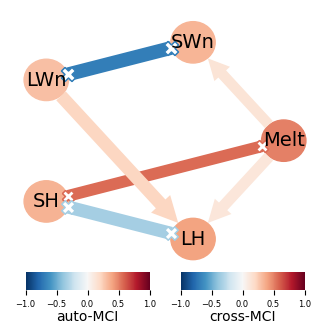

In [10]:
tp.plot_graph(
    graph=summary_graph,
    val_matrix=summary_val,
    link_width=summary_width,
    var_names=variables,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    figsize=(4, 3.4)
)

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/MAR/clean_mask/1975_2014/'
plt.savefig(
    plot_dir+f'graph_summary_mostfreq_across_4p_pcmciplus_MAR_realJJA_GrIS_ablation_noseasonality_1975_2014_conservative_alpha{pc_alpha_bootstrap}_taumax{tau_max}_bbl{boot_blocklength}_width{width_agg}.png',
    dpi=300, bbox_inches='tight', facecolor='w', transparent=False
)

In [11]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=summary_val,
    graph=summary_graph,
    var_names=variables,
    link_width=summary_width,
    save_name=home_dir+'2023-GrIS-melt-causality/data/MAR/graph_summary_mostfreq_across_4p_pcmciplus_bootstrap_melt_SEB_MAR_noGHF_realJJA_GrIS_ablation_RACMOmask_1975_2014_daily_conservative_nofdrc_robustparcorr_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv',
    digits=5,
)

In [12]:
save_name = home_dir+'2023-GrIS-melt-causality/data/MAR/graph_summary_mostfreq_across_4p_pcmciplus_bootstrap_melt_SEB_MAR_noGHF_realJJA_GrIS_ablation_RACMOmask_1975_2014_daily_conservative_nofdrc_robustparcorr_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,Melt,1,-->,0.50368,0.00000
1,Melt,SWn,0,-->,0.14041,0.57333
2,Melt,SH,0,x-x,0.56668,0.64000
3,Melt,LH,0,-->,0.12009,0.61000
4,SWn,SWn,1,-->,0.34340,0.00000
5,SWn,LWn,0,x-x,-0.69439,0.75250
6,LWn,LWn,1,-->,0.29833,0.00000
7,LWn,LH,0,-->,0.21544,0.70250
8,SH,SH,1,-->,0.34551,0.00000
9,SH,LH,0,x-x,-0.33645,0.71333


In [13]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/MAR/graph_summary_mostfreq_across_4p_pcmciplus_bootstrap_melt_SEB_MAR_noGHF_realJJA_GrIS_ablation_RACMOmask_1975_2014_daily_conservative_nofdrc_robustparcorr_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean_forplot.npz'

np.savez(save_name,
        val_matrix=summary_val,
        graph=summary_graph,
        var_names=variables,
        link_width=summary_width)

#### alpha = 0.05

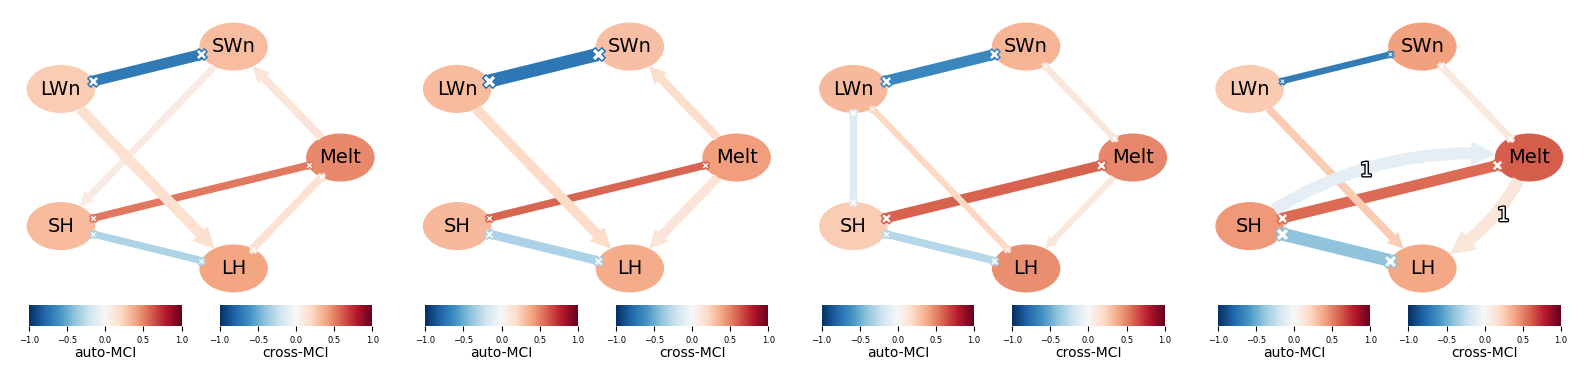

In [12]:
## Separate graphs
file = home_dir+'2023-GrIS-melt-causality/MAR/MARv3.14.0_GrIS_ablation_daily_vars_1975_2014_mask_1975_2014.nc'

# Define a 1x3 grid layout for 3 subplots
# without seasonality, alpha = 0.005
fig, axs = plt.subplots(1, 4, figsize=(16, 3.8))
axs = axs.flatten()  # Flatten to easily index subplots

pc_alpha_bootstrap = 0.05
boot_samples = 100
tau_max = 15

for n in range(4):
    if n == 0:
        int_vars = xr.open_dataset(file).sel(time=slice('1975-01-01','1984-12-31'))
    elif n == 1:
        int_vars = xr.open_dataset(file).sel(time=slice('1985-01-01','1994-12-31'))
    elif n == 2:
        int_vars = xr.open_dataset(file).sel(time=slice('1995-01-01','2004-12-31'))
    elif n == 3:
        int_vars = xr.open_dataset(file).sel(time=slice('2005-01-01','2014-12-31'))

    # The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
    # but its effect was not yet evaluated.
    boot_blocklength = 30

    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=True, add_mask=True, mask_period=np.arange(151,243))

    # Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments
    results = pcmci.run_bootstrap_of(
        method='run_pcmciplus',
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'},
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

    # Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
    boot_linkfreq = results['summary_results']['link_frequency']
    boot_graph = results['summary_results']['most_frequent_links']
    val_mat = results['summary_results']['val_matrix_mean']

    tp.plot_graph(
        graph = boot_graph,
        val_matrix= val_mat,
        link_width = boot_linkfreq,
        var_names=['Melt','SWn','LWn','SH','LH'],
        node_size=0.4,
        node_label_size=14,
        node_ticks=0.5,
        edge_ticks=0.5,
        link_label_fontsize=14,
        arrow_linewidth=10.0,
        link_colorbar_label='cross-MCI',
        node_colorbar_label='auto-MCI',
        fig_ax=(fig, axs[n])
        )

plt.tight_layout()
plot_dir = home_dir+'2023-GrIS-melt-causality/plot/MAR/clean_mask/1975_2014/'
plt.savefig(plot_dir+'graphs_pcmciplus_melt_SEB_noGHF_MAR_realJJA_GrIS_ablation_noseasonality_1975_2014_4p_conservative_nofdrc_robustparcorr_alpha'+str(pc_alpha_bootstrap)+'_taumax'+str(tau_max)+'_bbl'+str(boot_blocklength)+'.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [13]:
## Summary graph with most frequent link type
# --- settings ---
file = home_dir+'2023-GrIS-melt-causality/MAR/MARv3.14.0_GrIS_ablation_daily_vars_1975_2014_mask_1975_2014.nc'
variables = ['Melt','SWn','LWn','SH','LH']
num_vars = len(variables)

pc_alpha_bootstrap = 0.05
boot_samples = 100
tau_max = 15
boot_blocklength = 30
seed = 123

# Your real-JJA day-of-year mask (151..242)
mask_period = np.arange(151, 243)

period_slices = [
    ('1975-01-01','1984-12-31'),
    ('1985-01-01','1994-12-31'),
    ('1995-01-01','2004-12-31'),
    ('2005-01-01','2014-12-31')
]

# Storage: one entry per period
period_graphs = []      # boot_graph: (N, N, tau_max+1) strings
period_vals = []        # val_mat: (N, N, tau_max+1) float
period_linkfreqs = []   # boot_linkfreq: (N, N, tau_max+1) float

for (t0, t1) in period_slices:
    int_vars = xr.open_dataset(file).sel(time=slice(t0, t1))

    pcmci = process_prepare_pcmci(
        int_vars,
        remove_seasonal_cycle=True,
        add_mask=True,
        mask_period=mask_period
    )

    results = pcmci.run_bootstrap_of(
        method='run_pcmciplus',
        method_args={
            'tau_min': 0,
            'tau_max': tau_max,
            'pc_alpha': pc_alpha_bootstrap,
            'contemp_collider_rule': 'conservative'
        },
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=seed
    )

    boot_linkfreq = results['summary_results']['link_frequency']
    boot_graph    = results['summary_results']['most_frequent_links']
    val_mat       = results['summary_results']['val_matrix_mean']

    period_graphs.append(boot_graph)
    period_vals.append(val_mat)
    period_linkfreqs.append(boot_linkfreq)

# Convert to arrays for easier indexing:
# shapes:
#   graphs: (P, N, N, L)
#   vals  : (P, N, N, L)
#   freqs : (P, N, N, L)
graphs = np.stack(period_graphs, axis=0)
vals   = np.stack(period_vals, axis=0)
freqs  = np.stack(period_linkfreqs, axis=0)

P, N, _, L = graphs.shape
assert P == 4 and N == num_vars and L == tau_max + 1

In [14]:
def is_directed_link(t: str) -> bool:
    """
    Treat any link containing an arrow head/tail (< or >) as 'directed/partly-directed'.
    Undirected/no-link examples: '', 'o-o', 'x-x' (and None).
    """
    if t is None or t in ['', 'o-o', 'x-x']:
        return False
    return ('<' in t) or ('>' in t)

def choose_mode_with_directed_tiebreak(types, vals_for_types=None):
    """
    Pick the most frequent type. If tie (e.g., 2 vs 2), prefer directed over undirected.
    If still tied, optionally break tie by larger mean |val| (if vals_for_types provided),
    otherwise fall back to deterministic sorting.
    """
    c = Counter(types)
    max_count = max(c.values())
    candidates = [t for t, cnt in c.items() if cnt == max_count]

    # tie-break 1: prefer directed (includes partly-directed like o->, <-o, etc.)
    directed = [t for t in candidates if is_directed_link(t)]
    if directed:
        candidates = directed

    # tie-break 2 (optional): stronger mean absolute val among candidates
    if vals_for_types is not None:
        def mean_abs_val(t):
            vv = [abs(v) for tt, v in zip(types, vals_for_types) if tt == t and not np.isnan(v)]
            return np.mean(vv) if len(vv) else -np.inf
        chosen = max(candidates, key=mean_abs_val)
    else:
        # deterministic fallback
        chosen = sorted([str(t) for t in candidates])[0]

    return chosen, max_count

In [15]:
# Output containers
summary_graph = np.full((N, N, L), '', dtype=graphs.dtype)
summary_val   = np.full((N, N, L), np.nan, dtype=float)
summary_width = np.zeros((N, N, L), dtype=float)

# Choose how to aggregate link widths across periods
# - 'mean' matches your "average strength" idea
# - 'sum' makes widths larger if the link is stable across more periods
width_agg = 'mean'   # change to 'sum' if you prefer

for tau in range(L):
    for i in range(N):
        for j in range(N):
            if i == j:
                # keep self-links as they come (you can also summarize them, see note below)
                continue

            types = list(graphs[:, i, j, tau])  # length P

            # optional: use the corresponding period-mean val to break ties among directed candidates
            vals_for_types = list(vals[:, i, j, tau])

            mode_type, mode_count = choose_mode_with_directed_tiebreak(types, vals_for_types=vals_for_types)

            summary_graph[i, j, tau] = mode_type

            if mode_type == '' or mode_type is None:
                # No link most often -> leave val as NaN and width 0
                continue

            # Average val and width only over periods with that mode link type
            mask = (graphs[:, i, j, tau] == mode_type)

            # strength
            summary_val[i, j, tau] = np.nanmean(vals[mask, i, j, tau])

            # width
            if width_agg == 'mean':
                summary_width[i, j, tau] = np.nanmean(freqs[mask, i, j, tau])
            elif width_agg == 'sum':
                summary_width[i, j, tau] = np.nansum(freqs[mask, i, j, tau])
            else:
                raise ValueError("width_agg must be 'mean' or 'sum'")

In [16]:
node_self_vals = defaultdict(list)
node_self_sig  = defaultdict(list)

for p in range(P):
    g = graphs[p]
    v = vals[p]

    for i, var in enumerate(variables):
        self_series = v[i, i, 1:]  # tau=1..tau_max
        k = int(np.nanargmax(np.abs(self_series))) + 1
        max_val = float(np.nanmax(np.abs(self_series)))

        # Significant if the self-link type is not empty at that lag
        sig = (g[i, i, k] != '')

        node_self_vals[var].append(max_val)
        node_self_sig[var].append(sig)

# Majority rule across the 3 periods
summary_nodes = {}
for var in variables:
    sig_frac = np.mean(node_self_sig[var])
    summary_nodes[var] = np.mean(node_self_vals[var]) if sig_frac >= (2/3) else 0.0

node_colors = np.array([summary_nodes[v] for v in variables], dtype=float)

# Put node colors onto the diagonal at lag 1 for tp.plot_graph (your existing convention)
summary_val = summary_val.copy()
summary_graph = summary_graph.copy()
summary_val[np.arange(N), np.arange(N), 1] = node_colors
summary_graph[np.arange(N), np.arange(N), 1] = '-->'

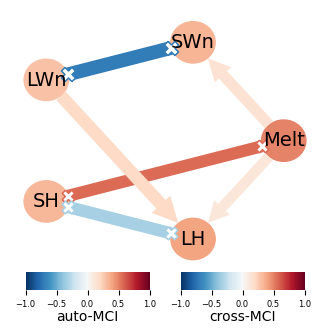

In [17]:
tp.plot_graph(
    graph=summary_graph,
    val_matrix=summary_val,
    link_width=summary_width,
    var_names=variables,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    figsize=(4, 3.4)
)

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/MAR/clean_mask/1975_2014/'
plt.savefig(
    plot_dir+f'graph_summary_mostfreq_across_4p_pcmciplus_MAR_realJJA_GrIS_ablation_noseasonality_1975_2014_conservative_alpha{pc_alpha_bootstrap}_taumax{tau_max}_bbl{boot_blocklength}_width{width_agg}.png',
    dpi=300, bbox_inches='tight', facecolor='w', transparent=False
)

In [18]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=summary_val,
    graph=summary_graph,
    var_names=variables,
    link_width=summary_width,
    save_name=home_dir+'2023-GrIS-melt-causality/data/MAR/graph_summary_mostfreq_across_4p_pcmciplus_bootstrap_melt_SEB_MAR_noGHF_realJJA_GrIS_ablation_RACMOmask_1975_2014_daily_conservative_nofdrc_robustparcorr_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv',
    digits=5,
)

In [19]:
save_name = home_dir+'2023-GrIS-melt-causality/data/MAR/graph_summary_mostfreq_across_4p_pcmciplus_bootstrap_melt_SEB_MAR_noGHF_realJJA_GrIS_ablation_RACMOmask_1975_2014_daily_conservative_nofdrc_robustparcorr_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,Melt,1,-->,0.49794,0.0000
1,Melt,SWn,0,-->,0.15119,0.5950
2,Melt,SH,0,x-x,0.56720,0.6525
3,Melt,LH,0,-->,0.11797,0.5650
4,SWn,SWn,1,-->,0.34180,0.0000
5,SWn,LWn,0,x-x,-0.69554,0.7450
6,LWn,LWn,1,-->,0.28935,0.0000
7,LWn,LH,0,-->,0.20154,0.6800
8,SH,SH,1,-->,0.33238,0.0000
9,SH,LH,0,x-x,-0.32833,0.6625


In [20]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/MAR/graph_summary_mostfreq_across_4p_pcmciplus_bootstrap_melt_SEB_MAR_noGHF_realJJA_GrIS_ablation_RACMOmask_1975_2014_daily_conservative_nofdrc_robustparcorr_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean_forplot.npz'

np.savez(save_name,
        val_matrix=summary_val,
        graph=summary_graph,
        var_names=variables,
        link_width=summary_width)

#### alpha = 0.1

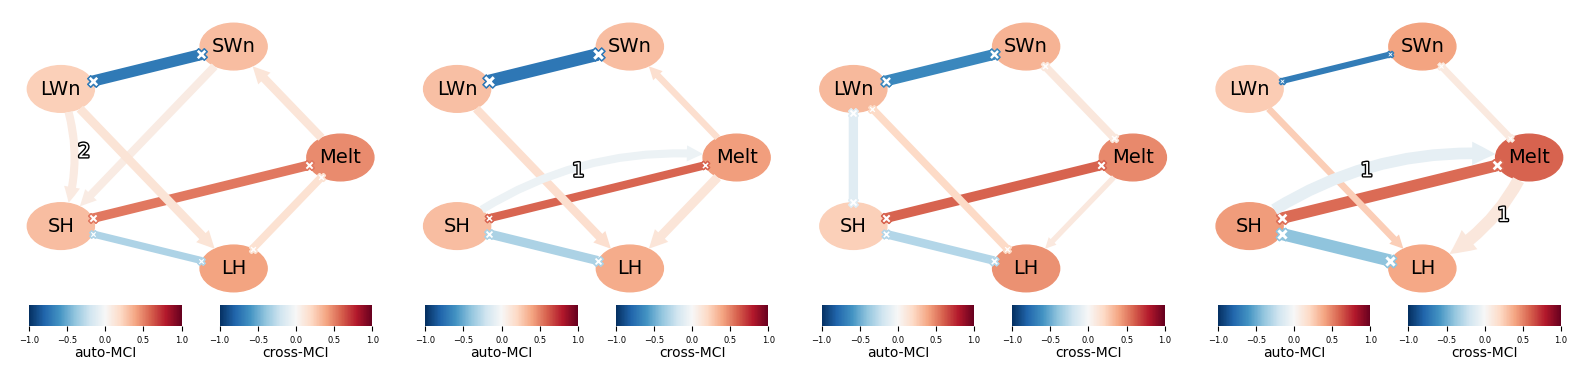

In [21]:
## Separate graphs
file = home_dir+'2023-GrIS-melt-causality/MAR/MARv3.14.0_GrIS_ablation_daily_vars_1975_2014_mask_1975_2014.nc'

# Define a 1x3 grid layout for 3 subplots
# without seasonality, alpha = 0.005
fig, axs = plt.subplots(1, 4, figsize=(16, 3.8))
axs = axs.flatten()  # Flatten to easily index subplots

pc_alpha_bootstrap = 0.1
boot_samples = 100
tau_max = 15

for n in range(4):
    if n == 0:
        int_vars = xr.open_dataset(file).sel(time=slice('1975-01-01','1984-12-31'))
    elif n == 1:
        int_vars = xr.open_dataset(file).sel(time=slice('1985-01-01','1994-12-31'))
    elif n == 2:
        int_vars = xr.open_dataset(file).sel(time=slice('1995-01-01','2004-12-31'))
    elif n == 3:
        int_vars = xr.open_dataset(file).sel(time=slice('2005-01-01','2014-12-31'))

    # The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
    # but its effect was not yet evaluated.
    boot_blocklength = 30

    pcmci = process_prepare_pcmci(int_vars, remove_seasonal_cycle=True, add_mask=True, mask_period=np.arange(151,243))

    # Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments
    results = pcmci.run_bootstrap_of(
        method='run_pcmciplus',
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'},
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

    # Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
    boot_linkfreq = results['summary_results']['link_frequency']
    boot_graph = results['summary_results']['most_frequent_links']
    val_mat = results['summary_results']['val_matrix_mean']

    tp.plot_graph(
        graph = boot_graph,
        val_matrix= val_mat,
        link_width = boot_linkfreq,
        var_names=['Melt','SWn','LWn','SH','LH'],
        node_size=0.4,
        node_label_size=14,
        node_ticks=0.5,
        edge_ticks=0.5,
        link_label_fontsize=14,
        arrow_linewidth=10.0,
        link_colorbar_label='cross-MCI',
        node_colorbar_label='auto-MCI',
        fig_ax=(fig, axs[n])
        )

plt.tight_layout()
plot_dir = home_dir+'2023-GrIS-melt-causality/plot/MAR/clean_mask/1975_2014/'
plt.savefig(plot_dir+'graphs_pcmciplus_melt_SEB_noGHF_MAR_realJJA_GrIS_ablation_noseasonality_1975_2014_4p_conservative_nofdrc_robustparcorr_alpha'+str(pc_alpha_bootstrap)+'_taumax'+str(tau_max)+'_bbl'+str(boot_blocklength)+'.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

In [22]:
## Summary graph with most frequent link type
# --- settings ---
file = home_dir+'2023-GrIS-melt-causality/MAR/MARv3.14.0_GrIS_ablation_daily_vars_1975_2014_mask_1975_2014.nc'
variables = ['Melt','SWn','LWn','SH','LH']
num_vars = len(variables)

pc_alpha_bootstrap = 0.1
boot_samples = 100
tau_max = 15
boot_blocklength = 30
seed = 123

# Your real-JJA day-of-year mask (151..242)
mask_period = np.arange(151, 243)

period_slices = [
    ('1975-01-01','1984-12-31'),
    ('1985-01-01','1994-12-31'),
    ('1995-01-01','2004-12-31'),
    ('2005-01-01','2014-12-31')
]

# Storage: one entry per period
period_graphs = []      # boot_graph: (N, N, tau_max+1) strings
period_vals = []        # val_mat: (N, N, tau_max+1) float
period_linkfreqs = []   # boot_linkfreq: (N, N, tau_max+1) float

for (t0, t1) in period_slices:
    int_vars = xr.open_dataset(file).sel(time=slice(t0, t1))

    pcmci = process_prepare_pcmci(
        int_vars,
        remove_seasonal_cycle=True,
        add_mask=True,
        mask_period=mask_period
    )

    results = pcmci.run_bootstrap_of(
        method='run_pcmciplus',
        method_args={
            'tau_min': 0,
            'tau_max': tau_max,
            'pc_alpha': pc_alpha_bootstrap,
            'contemp_collider_rule': 'conservative'
        },
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=seed
    )

    boot_linkfreq = results['summary_results']['link_frequency']
    boot_graph    = results['summary_results']['most_frequent_links']
    val_mat       = results['summary_results']['val_matrix_mean']

    period_graphs.append(boot_graph)
    period_vals.append(val_mat)
    period_linkfreqs.append(boot_linkfreq)

# Convert to arrays for easier indexing:
# shapes:
#   graphs: (P, N, N, L)
#   vals  : (P, N, N, L)
#   freqs : (P, N, N, L)
graphs = np.stack(period_graphs, axis=0)
vals   = np.stack(period_vals, axis=0)
freqs  = np.stack(period_linkfreqs, axis=0)

P, N, _, L = graphs.shape
assert P == 4 and N == num_vars and L == tau_max + 1

In [23]:
def is_directed_link(t: str) -> bool:
    """
    Treat any link containing an arrow head/tail (< or >) as 'directed/partly-directed'.
    Undirected/no-link examples: '', 'o-o', 'x-x' (and None).
    """
    if t is None or t in ['', 'o-o', 'x-x']:
        return False
    return ('<' in t) or ('>' in t)

def choose_mode_with_directed_tiebreak(types, vals_for_types=None):
    """
    Pick the most frequent type. If tie (e.g., 2 vs 2), prefer directed over undirected.
    If still tied, optionally break tie by larger mean |val| (if vals_for_types provided),
    otherwise fall back to deterministic sorting.
    """
    c = Counter(types)
    max_count = max(c.values())
    candidates = [t for t, cnt in c.items() if cnt == max_count]

    # tie-break 1: prefer directed (includes partly-directed like o->, <-o, etc.)
    directed = [t for t in candidates if is_directed_link(t)]
    if directed:
        candidates = directed

    # tie-break 2 (optional): stronger mean absolute val among candidates
    if vals_for_types is not None:
        def mean_abs_val(t):
            vv = [abs(v) for tt, v in zip(types, vals_for_types) if tt == t and not np.isnan(v)]
            return np.mean(vv) if len(vv) else -np.inf
        chosen = max(candidates, key=mean_abs_val)
    else:
        # deterministic fallback
        chosen = sorted([str(t) for t in candidates])[0]

    return chosen, max_count

In [24]:
# Output containers
summary_graph = np.full((N, N, L), '', dtype=graphs.dtype)
summary_val   = np.full((N, N, L), np.nan, dtype=float)
summary_width = np.zeros((N, N, L), dtype=float)

# Choose how to aggregate link widths across periods
# - 'mean' matches your "average strength" idea
# - 'sum' makes widths larger if the link is stable across more periods
width_agg = 'mean'   # change to 'sum' if you prefer

for tau in range(L):
    for i in range(N):
        for j in range(N):
            if i == j:
                # keep self-links as they come (you can also summarize them, see note below)
                continue

            types = list(graphs[:, i, j, tau])  # length P

            # optional: use the corresponding period-mean val to break ties among directed candidates
            vals_for_types = list(vals[:, i, j, tau])

            mode_type, mode_count = choose_mode_with_directed_tiebreak(types, vals_for_types=vals_for_types)

            summary_graph[i, j, tau] = mode_type

            if mode_type == '' or mode_type is None:
                # No link most often -> leave val as NaN and width 0
                continue

            # Average val and width only over periods with that mode link type
            mask = (graphs[:, i, j, tau] == mode_type)

            # strength
            summary_val[i, j, tau] = np.nanmean(vals[mask, i, j, tau])

            # width
            if width_agg == 'mean':
                summary_width[i, j, tau] = np.nanmean(freqs[mask, i, j, tau])
            elif width_agg == 'sum':
                summary_width[i, j, tau] = np.nansum(freqs[mask, i, j, tau])
            else:
                raise ValueError("width_agg must be 'mean' or 'sum'")

In [25]:
node_self_vals = defaultdict(list)
node_self_sig  = defaultdict(list)

for p in range(P):
    g = graphs[p]
    v = vals[p]

    for i, var in enumerate(variables):
        self_series = v[i, i, 1:]  # tau=1..tau_max
        k = int(np.nanargmax(np.abs(self_series))) + 1
        max_val = float(np.nanmax(np.abs(self_series)))

        # Significant if the self-link type is not empty at that lag
        sig = (g[i, i, k] != '')

        node_self_vals[var].append(max_val)
        node_self_sig[var].append(sig)

# Majority rule across the 3 periods
summary_nodes = {}
for var in variables:
    sig_frac = np.mean(node_self_sig[var])
    summary_nodes[var] = np.mean(node_self_vals[var]) if sig_frac >= (2/3) else 0.0

node_colors = np.array([summary_nodes[v] for v in variables], dtype=float)

# Put node colors onto the diagonal at lag 1 for tp.plot_graph (your existing convention)
summary_val = summary_val.copy()
summary_graph = summary_graph.copy()
summary_val[np.arange(N), np.arange(N), 1] = node_colors
summary_graph[np.arange(N), np.arange(N), 1] = '-->'

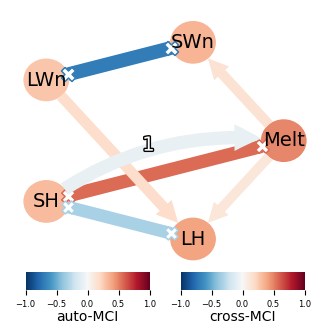

In [26]:
tp.plot_graph(
    graph=summary_graph,
    val_matrix=summary_val,
    link_width=summary_width,
    var_names=variables,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    figsize=(4, 3.4)
)

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/MAR/clean_mask/1975_2014/'
plt.savefig(
    plot_dir+f'graph_summary_mostfreq_across_4p_pcmciplus_MAR_realJJA_GrIS_ablation_noseasonality_1975_2014_conservative_alpha{pc_alpha_bootstrap}_taumax{tau_max}_bbl{boot_blocklength}_width{width_agg}.png',
    dpi=300, bbox_inches='tight', facecolor='w', transparent=False
)

In [27]:
#The links can also be exported to a csv file:
tp.write_csv(
    val_matrix=summary_val,
    graph=summary_graph,
    var_names=variables,
    link_width=summary_width,
    save_name=home_dir+'2023-GrIS-melt-causality/data/MAR/graph_summary_mostfreq_across_4p_pcmciplus_bootstrap_melt_SEB_MAR_noGHF_realJJA_GrIS_ablation_RACMOmask_1975_2014_daily_conservative_nofdrc_robustparcorr_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv',
    digits=5,
)

In [28]:
save_name = home_dir+'2023-GrIS-melt-causality/data/MAR/graph_summary_mostfreq_across_4p_pcmciplus_bootstrap_melt_SEB_MAR_noGHF_realJJA_GrIS_ablation_RACMOmask_1975_2014_daily_conservative_nofdrc_robustparcorr_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean.csv'
pd.read_csv(save_name)

,Variable i,Variable j,Time lag of i,Link type i --- j,Link value,Link width
0,Melt,Melt,1,-->,0.489170,0.0000
1,Melt,SWn,0,-->,0.150520,0.5400
2,Melt,SH,0,x-x,0.567750,0.7075
3,Melt,LH,0,-->,0.117830,0.5250
4,SWn,SWn,1,-->,0.340450,0.0000
5,SWn,LWn,0,x-x,-0.696220,0.7375
6,LWn,LWn,1,-->,0.280860,0.0000
7,LWn,LH,0,-->,0.185840,0.5700
8,SH,Melt,1,-->,-0.075582,0.7100
9,SH,SH,1,-->,0.319930,0.0000


In [29]:
# Save for plotting (since the format saved by tp.write_csv is hard to use)
save_name = home_dir+'2023-GrIS-melt-causality/data/MAR/graph_summary_mostfreq_across_4p_pcmciplus_bootstrap_melt_SEB_MAR_noGHF_realJJA_GrIS_ablation_RACMOmask_1975_2014_daily_conservative_nofdrc_robustparcorr_maxtau'+str(tau_max)+'_alpha'+str(pc_alpha_bootstrap)+'_bbl'+str(boot_blocklength)+'_clean_forplot.npz'

np.savez(save_name,
        val_matrix=summary_val,
        graph=summary_graph,
        var_names=variables,
        link_width=summary_width)

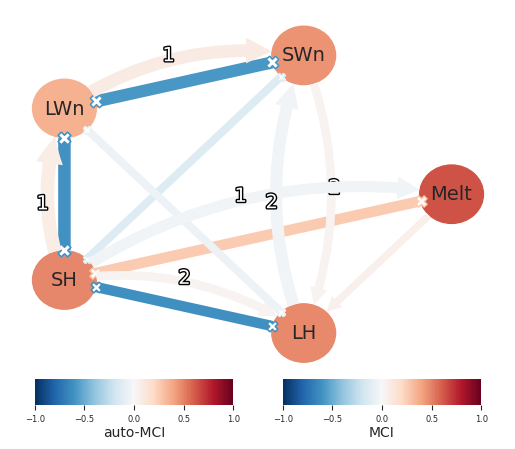

In [51]:
# alpha = 0.025
pc_alpha_bootstrap = 0.025
boot_samples = 100
tau_max = 15

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 1

## Create PCMCI object to call run_bootstrap_of
robustparcorr = RobustParCorr(significance='analytic')
pcmci = PCMCI(dataframe=dataframe,
        cond_ind_test=robustparcorr,
        verbosity=0,
        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=dataframe.var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/MAR/clean_mask/'
plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_SEB_MAR_noGHF_JJA_GrIS_ablation_1985_2014_daily_robustparcorr_conservative_nofdrc_alpha0025_taumax15.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

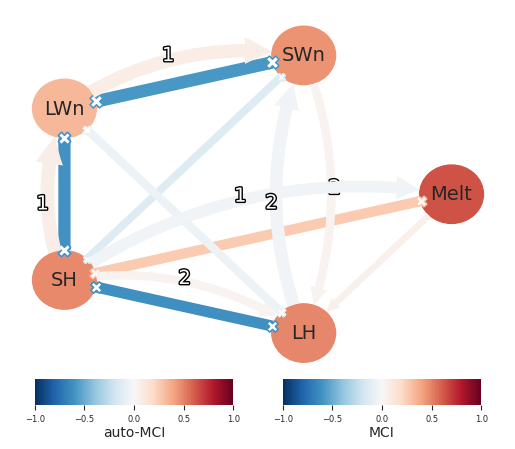

In [52]:
# alpha = 0.05
pc_alpha_bootstrap = 0.05
boot_samples = 100
tau_max = 15

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 1

## Create PCMCI object to call run_bootstrap_of
robustparcorr = RobustParCorr(significance='analytic')
pcmci = PCMCI(dataframe=dataframe,
        cond_ind_test=robustparcorr,
        verbosity=0,
        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=dataframe.var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/MAR/clean_mask/'
plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_SEB_MAR_noGHF_JJA_GrIS_ablation_1985_2014_daily_robustparcorr_conservative_nofdrc_alpha005_taumax15.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

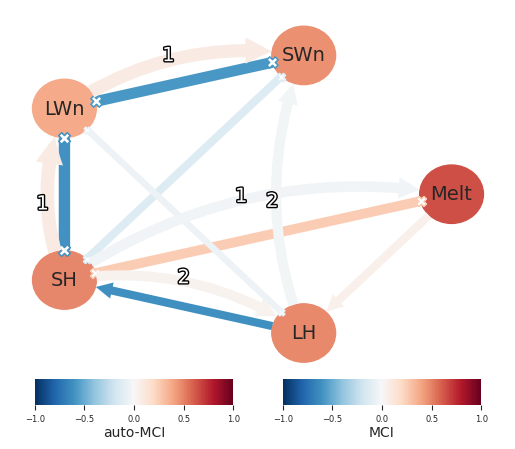

In [57]:
# alpha = None
pc_alpha_bootstrap = None
boot_samples = 100
tau_max = 15

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 1

## Create PCMCI object to call run_bootstrap_of
robustparcorr = RobustParCorr(significance='analytic')
pcmci = PCMCI(dataframe=dataframe,
        cond_ind_test=robustparcorr,
        verbosity=0,
        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=dataframe.var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/MAR/clean_mask/'
plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_SEB_MAR_noGHF_JJA_GrIS_ablation_1985_2014_daily_robustparcorr_conservative_nofdrc_alphaNone_taumax15.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

### cond_ind_test=robustparcorr, tau_max = 5

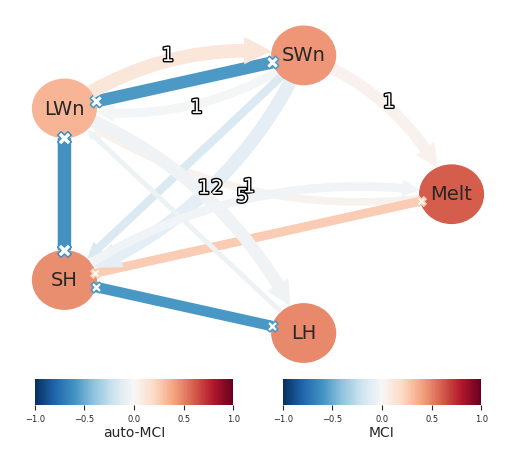

In [21]:
# alpha = 0.005
pc_alpha_bootstrap = 0.005
boot_samples = 100
tau_max = 5

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 1

## Create PCMCI object to call run_bootstrap_of
robustparcorr = RobustParCorr(significance='analytic')
pcmci = PCMCI(dataframe=dataframe,
        cond_ind_test=robustparcorr,
        verbosity=0,
        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=dataframe.var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/MAR/clean_mask/'
plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_SEB_MAR_noGHF_JJA_GrIS_ablation_1940_1969_daily_robustparcorr_conservative_nofdrc_alpha0005_taumax5.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

### cond_ind_test=robustparcorr, tau_max = 25

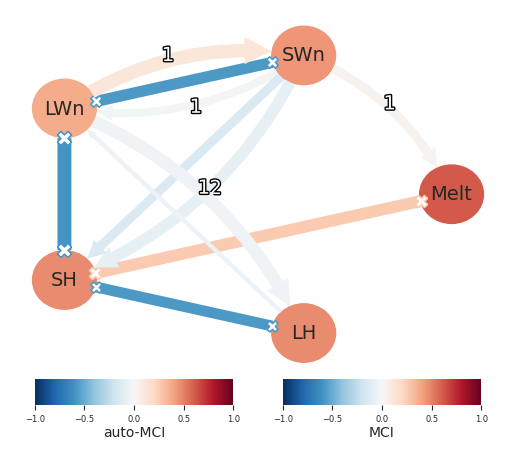

In [22]:
# alpha = 0.005
pc_alpha_bootstrap = 0.005
boot_samples = 100
tau_max = 25

# The block-length of the bootstrap can optionally be used to better deal with autocorrelation, 
# but its effect was not yet evaluated.
boot_blocklength = 1

## Create PCMCI object to call run_bootstrap_of
robustparcorr = RobustParCorr(significance='analytic')
pcmci = PCMCI(dataframe=dataframe,
        cond_ind_test=robustparcorr,
        verbosity=0,
        )

# Call bootstrap for the chosen method (here 'run_pcmciplus') and pass method arguments  
results = pcmci.run_bootstrap_of(
        method='run_pcmciplus', 
        method_args={'tau_max':tau_max, 'pc_alpha':pc_alpha_bootstrap, 'contemp_collider_rule':'conservative'}, 
        boot_samples=boot_samples,
        boot_blocklength=boot_blocklength,
        seed=123)

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
boot_linkfreq = results['summary_results']['link_frequency']
boot_graph = results['summary_results']['most_frequent_links']
val_mat = results['summary_results']['val_matrix_mean']

# Plot
tp.plot_graph(
    graph = boot_graph,
    val_matrix= val_mat,
    link_width = boot_linkfreq,
    var_names=dataframe.var_names,
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plot_dir = home_dir+'2023-GrIS-melt-causality/plot/MAR/clean_mask/'
plt.savefig(plot_dir+'graph_pcmciplus_bootstrap_melt_SEB_MAR_noGHF_JJA_GrIS_ablation_1940_1969_daily_robustparcorr_conservative_nofdrc_alpha0005_taumax25.png', dpi=300, bbox_inches='tight', facecolor='w', transparent=False)

### cond_ind_test=gpdc, tau_max = 15

Couldn't finish with bootstrap

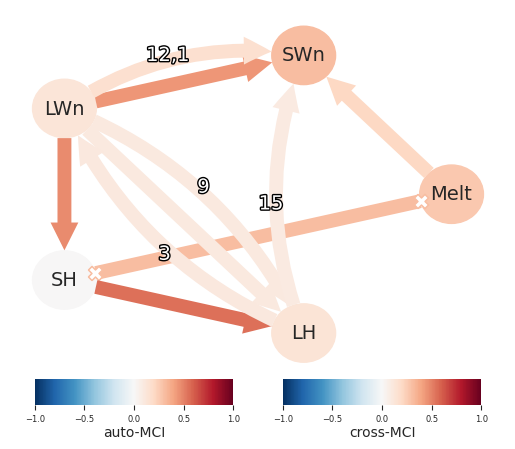

In [66]:
## alpha = 0.05

# Create PCMCI object
gpdc = GPDC(significance='analytic', gp_params=None)
pcmci = PCMCI(dataframe=dataframe,
        cond_ind_test=gpdc,
        verbosity=0,
        )

# Run pcmciplus
results = pcmci.run_pcmciplus(tau_min=0, tau_max=15, pc_alpha=0.05, contemp_collider_rule='conservative') #reset_lagged_links=True adds more links to piControl case, not 4xext

# Output graph, link frequencies (confidence measure), and mean test statistic values (val_mat)
tp.plot_graph(
    val_matrix=results['val_matrix'],
    graph=results['graph'],
    var_names=var_names,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    node_size=0.4,
    node_label_size=14,
    node_ticks=0.5,
    edge_ticks=0.5,
    link_label_fontsize=14,
    arrow_linewidth=10.0,
    );

plt.savefig(home_dir+'GrIS_melt_causality/plot/RACMO_ERA5/graph_pcmciplus_melt_RACMO_SEB_ERA5_noGHF_JJA_GrIS_ablation_1958_2022_gpdc_conservative_nofdrc.png', dpi = 300, bbox_inches = 'tight', facecolor='w', transparent = False)